# Import libraries and data upload

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
import math
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
import xgboost as xgb
import shap
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_validate, GridSearchCV, cross_validate, cross_val_predict, ShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import learning_curve, validation_curve, cross_val_score
from scipy.stats import zscore
import pprint
import joblib

In [2]:
train_df = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\Property_prices_predictions\train.csv')
test_df = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\Property_prices_predictions\test.csv')
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Data cleaning

In [3]:
print(train_df.shape)
print(test_df.shape)

(1460, 81)
(1459, 80)


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
test_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [7]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The dataset contains 1,460 residential property records and 81 features describing physical attributes, quality ratings, amenities, and location characteristics, along with the final sale price. There is a mix of numerical variables and categorical variables. A noticeable portion of the missing data is concentrated in features related to optional property elements such as basements, garages, masonry veneer, pools, and fences. This pattern indicates that the missingness is largely structural rather than random data loss. The descriptive statistics also show substantial variation in square footage and overall quality ratings, suggesting that the dataset captures a wide range of housing market segments—from small, lower-quality properties to large, high-end homes. This variation is essential for distinguishing price drivers in subsequent analysis.

### Missigness

In [8]:
# Missing value summary
missing_summary = (
    train_df.isnull().sum()
    .to_frame("Missing_Values")
    .assign(Percent=lambda df: 100 * df["Missing_Values"] / len(train_df))
    .query("Missing_Values > 0")
    .sort_values("Missing_Values", ascending=False)
)

missing_summary

,Missing_Values,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [9]:
missing_summary = (
    test_df.isnull().sum()
    .to_frame("Missing_Values")
    .assign(Percent=lambda df: 100 * df["Missing_Values"] / len(test_df))
    .query("Missing_Values > 0")
    .sort_values("Missing_Values", ascending=False)
)

missing_summary

,Missing_Values,Percent
PoolQC,1456,99.794380
MiscFeature,1408,96.504455
Alley,1352,92.666210
Fence,1169,80.123372
MasVnrType,894,61.274846
FireplaceQu,730,50.034270
LotFrontage,227,15.558602
GarageQual,78,5.346127
GarageCond,78,5.346127
GarageYrBlt,78,5.346127


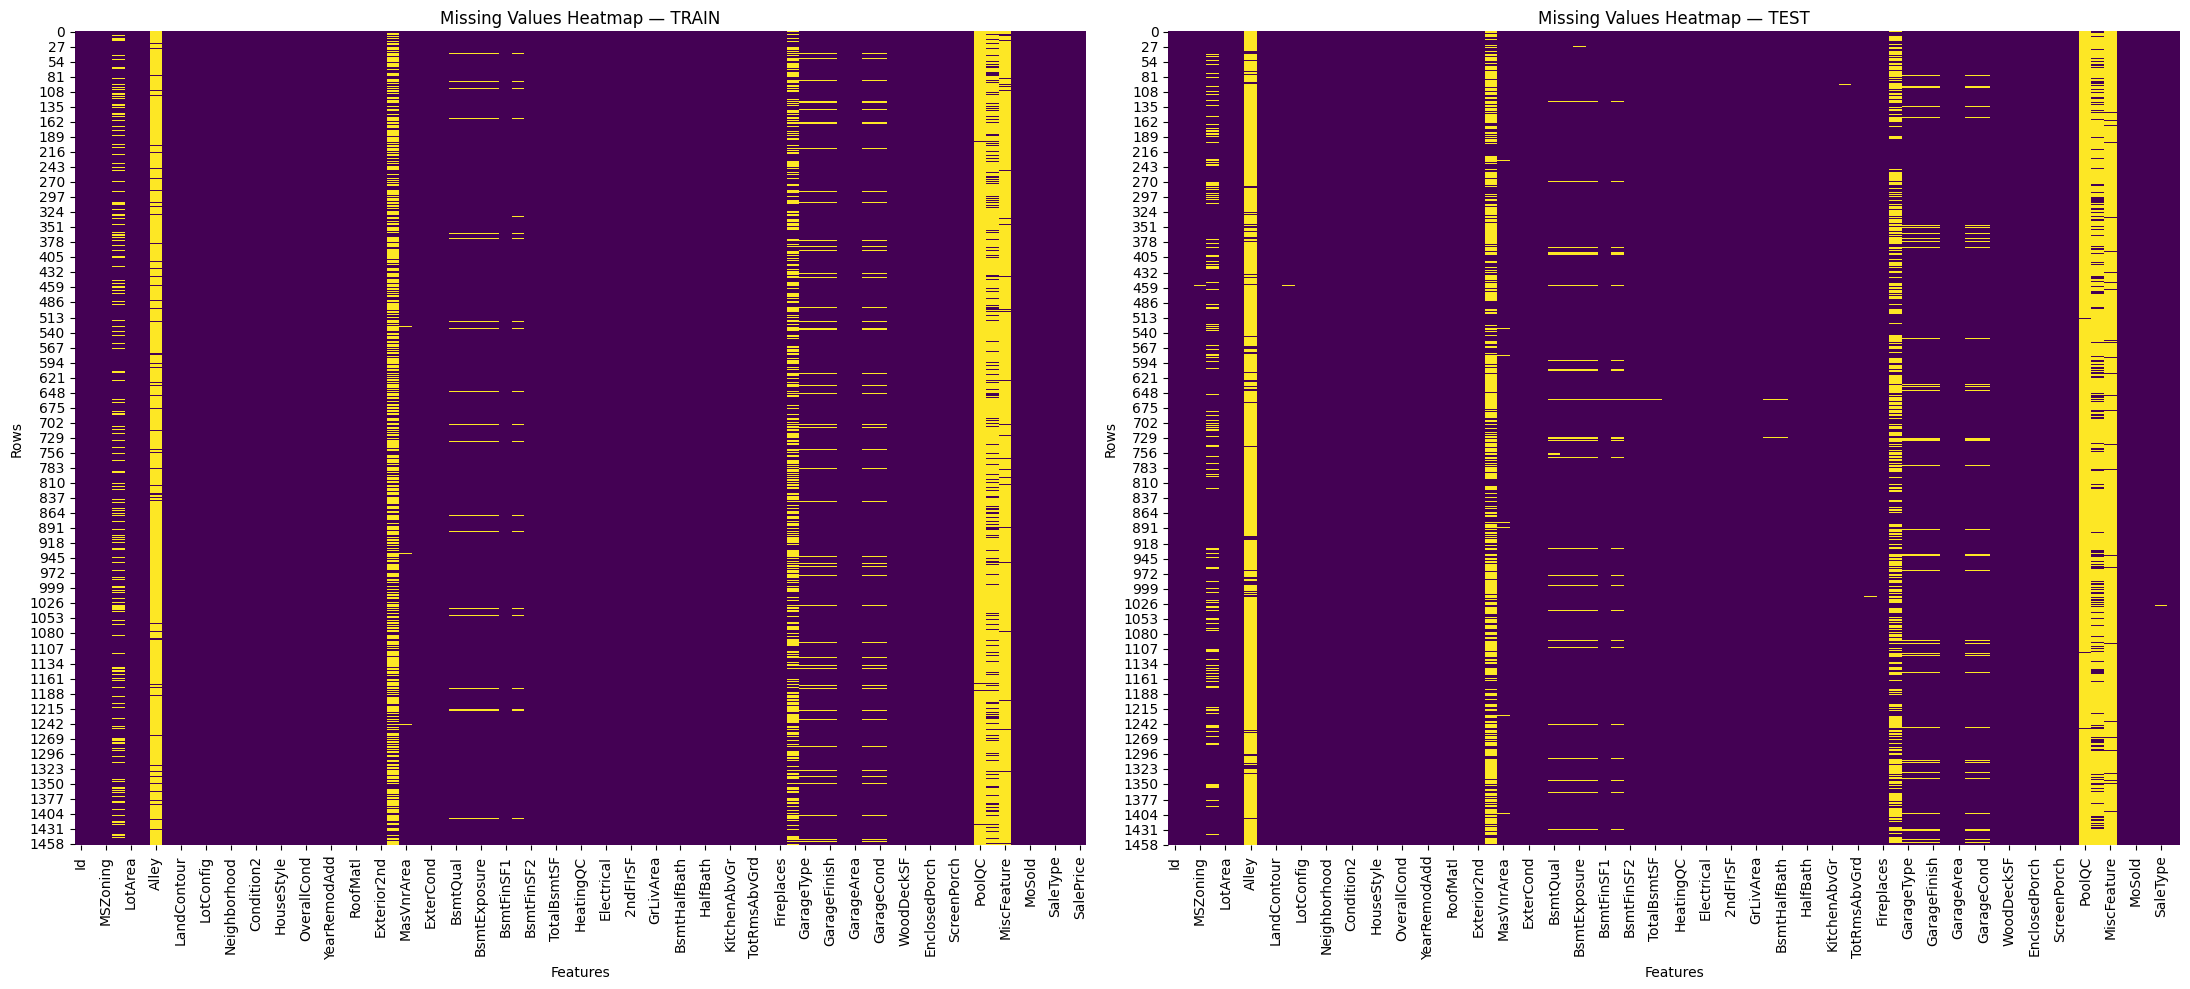

In [10]:
# missingness heatmap
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(train_df.isna(), cbar=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Missing Values Heatmap — TRAIN")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Rows")

sns.heatmap(test_df.isna(), cbar=False, cmap="viridis", ax=axes[1])
axes[1].set_title("Missing Values Heatmap — TEST")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

In [ ]:
# Missing Value Handling
from collections import Counter

train = train_df.copy()
test = test_df.copy()

filled_counts = Counter()
impute_info = {}

def safe_mode(series):
    s = series.dropna()
    return s.mode().iloc[0] if not s.empty else None

# GARAGE FEATURES
if 'GarageType' in train.columns:
    garage_stats = {}
    for col in ['GarageArea', 'GarageCars', 'GarageYrBlt']:
        if col in train.columns:
            garage_stats[col] = train.groupby('GarageType')[col].median().to_dict()
    impute_info['garage_stats'] = garage_stats

    def fill_garage(df, stats):
        if 'GarageType' not in df.columns: return df
        for col, mapping in stats.items():
            if col not in df.columns: continue
            # If GarageType == 'None' → fill with 0
            none_mask = (df['GarageType'] == 'None') & df[col].isna()
            df.loc[none_mask, col] = 0
            filled_counts[f'{col}_garage_none_to_0'] += int(none_mask.sum())

            # Fill other missing with GarageType median
            mask = df[col].isna() & df['GarageType'].notna() & (df['GarageType'] != 'None')
            if mask.any():
                global_med = np.nanmedian(list(mapping.values())) if mapping else 0
                df.loc[mask, col] = df.loc[mask, 'GarageType'].map(mapping).fillna(global_med)
                filled_counts[f'{col}_garage_type_median'] += int(mask.sum())
        return df

    train = fill_garage(train, garage_stats)
    test  = fill_garage(test, garage_stats)

#  FIREPLACE
if 'Fireplaces' in train.columns and 'FireplaceQu' in train.columns:
    fire_mode_map = {k: safe_mode(v) for k, v in train.groupby('Fireplaces')['FireplaceQu']}
    overall_fire_mode = safe_mode(train.loc[train['Fireplaces'] > 0, 'FireplaceQu'])
    impute_info['fireplace_mode_by_count'] = fire_mode_map

    def fill_fireplace(df):
        if 'FireplaceQu' not in df.columns: return df
        mask_fire = (df['Fireplaces'] > 0) & df['FireplaceQu'].isna()
        df.loc[mask_fire, 'FireplaceQu'] = df.loc[mask_fire, 'Fireplaces'].map(fire_mode_map).fillna(overall_fire_mode)
        filled_counts['fireplace_quality_filled'] += int(mask_fire.sum())

        zero_mask = (df['Fireplaces'] == 0)
        df.loc[zero_mask, 'FireplaceQu'] = 'None'
        filled_counts['fireplace_none_for_zero'] += int(zero_mask.sum())
        return df

    train = fill_fireplace(train)
    test  = fill_fireplace(test)

# BASEMENT
bsmt_cat = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']
bsmt_num = ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']

bsmt_mode_by_neigh = {c: train.groupby('Neighborhood')[c].agg(lambda s: safe_mode(s)).dropna().to_dict()
                      for c in bsmt_cat if 'Neighborhood' in train.columns}
bsmt_med_by_neigh = {c: train.groupby('Neighborhood')[c].median().dropna().to_dict()
                     for c in bsmt_num if 'Neighborhood' in train.columns}

def fill_basement(df):
    if 'TotalBsmtSF' not in df.columns: return df
    no_bsmt = df['TotalBsmtSF'] == 0
    # No basement
    for c in bsmt_cat:
        if c in df.columns:
            df.loc[no_bsmt, c] = 'None'
            filled_counts[f'{c}_no_bsmt_set_none'] += int(no_bsmt.sum())
    for c in bsmt_num:
        if c in df.columns:
            df.loc[no_bsmt, c] = 0
            filled_counts[f'{c}_no_bsmt_set_zero'] += int(no_bsmt.sum())

    # Has basement but missing → fill by neighborhood
    has_bsmt = df['TotalBsmtSF'] > 0
    for c in bsmt_cat:
        if c in df.columns:
            global_mode = safe_mode(train[c]) if c in train.columns else 'None'
            neigh_map = bsmt_mode_by_neigh.get(c, {})
            mask = has_bsmt & df[c].isna()
            df.loc[mask, c] = df.loc[mask, 'Neighborhood'].map(neigh_map).fillna(global_mode)
            filled_counts[f'{c}_filled_by_neigh'] += int(mask.sum())
    for c in bsmt_num:
        if c in df.columns:
            global_med = float(train[c].median()) if c in train.columns else 0
            neigh_map = bsmt_med_by_neigh.get(c, {})
            mask = has_bsmt & df[c].isna()
            df.loc[mask, c] = df.loc[mask, 'Neighborhood'].map(neigh_map).fillna(global_med)
            filled_counts[f'{c}_filled_by_neigh'] += int(mask.sum())
    return df

train = fill_basement(train)
test  = fill_basement(test)

# MASONRY
if 'MasVnrType' in train.columns and 'MasVnrArea' in train.columns:
    mas_med = train.groupby('MasVnrType')['MasVnrArea'].median().to_dict()
    impute_info['mas_median'] = mas_med

    def fill_mas(df):
        mask_none = df['MasVnrType'] == 'None'
        df.loc[mask_none, 'MasVnrArea'] = 0
        mask_fill = df['MasVnrType'].notna() & (df['MasVnrType'] != 'None') & df['MasVnrArea'].isna()
        df.loc[mask_fill, 'MasVnrArea'] = df.loc[mask_fill, 'MasVnrType'].map(mas_med).fillna(np.nanmedian(list(mas_med.values())))
        filled_counts['mas_area_filled'] += int(mask_fill.sum())
        return df

    train = fill_mas(train)
    test  = fill_mas(test)

# POOL
if 'PoolArea' in train.columns and 'PoolQC' in train.columns:
    pool_mode = safe_mode(train.loc[train['PoolArea'] > 0, 'PoolQC'])
    impute_info['pool_mode'] = pool_mode

    def fill_pool(df):
        mask_pool = (df['PoolArea'] > 0) & df['PoolQC'].isna()
        df.loc[mask_pool, 'PoolQC'] = pool_mode
        zero_mask = (df['PoolArea'] == 0)
        df.loc[zero_mask, 'PoolQC'] = 'None'
        filled_counts['pool_filled'] += int(mask_pool.sum())
        return df

    train = fill_pool(train)
    test  = fill_pool(test)

# LOTFRONTAGE
if 'LotFrontage' in train.columns and 'Neighborhood' in train.columns:
    neigh_medians = train.groupby('Neighborhood')['LotFrontage'].median()
    global_med = train['LotFrontage'].median()

    def fill_lotfrontage(df):
        mask = df['LotFrontage'].isna()
        df.loc[mask, 'LotFrontage'] = df.loc[mask, 'Neighborhood'].map(neigh_medians).fillna(global_med)
        filled_counts['lotfrontage_filled'] += int(mask.sum())
        return df

    train = fill_lotfrontage(train)
    test  = fill_lotfrontage(test)

# SMALL-MISSING CATEGORICAL
fill_mode_cols = ['Electrical','MSZoning','Utilities','SaleType','Exterior1st','Exterior2nd','Functional']
for col in fill_mode_cols:
    if col in train.columns:
        mode_val = safe_mode(train[col])
        train[col] = train[col].fillna(mode_val)
        if col in test.columns:
            test[col] = test[col].fillna(mode_val)
        filled_counts[f'{col}_mode_filled'] += int(train[col].isna().sum())


for df, name in [(train, "train"), (test, "test")]:
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(0)
            else:
                df[col] = df[col].fillna('None')
            filled_counts[f'{name}_{col}_final_safety'] += int(df[col].isna().sum())

print("\nRemaining NaNs (train):", train.isna().sum().sum())
print("Remaining NaNs (test):", test.isna().sum().sum())


Remaining NaNs (train): 0
Remaining NaNs (test): 0


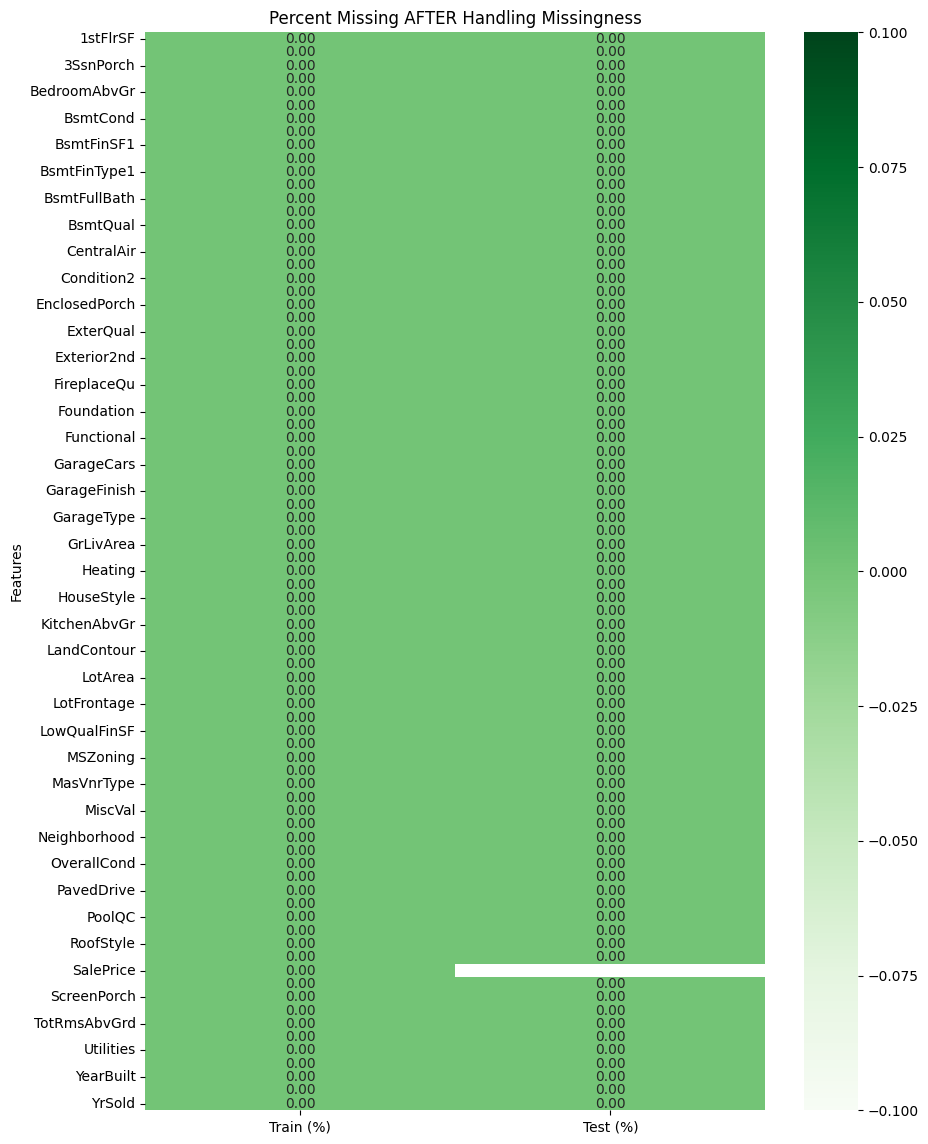

In [12]:
# after handling missingness heatmap
missing_summary_after = pd.DataFrame({
    "Train (%)": train.isna().mean() * 100,
    "Test (%)": test.isna().mean() * 100
})

plt.figure(figsize=(10, 14))
sns.heatmap(missing_summary_after, annot=True, fmt=".2f", cmap="Greens")
plt.title("Percent Missing AFTER Handling Missingness")
plt.ylabel("Features")
plt.show()

I applied a structured, domain-aware strategy to treat missing data:

Structural Absence: Features like PoolQC, Alley, Fence, FireplaceQu, Basement and Garage attributes were missing because the house does not have that feature. These were filled with "None" (categorical) or 0 (numeric area/count fields).

Conditional Filling: For features that depend on another feature
(e.g., MasVnrArea → MasVnrType, GarageYrBlt → GarageType), we used the median of similar houses when the feature exists, and 0 when it doesn't.

Neighborhood-Based Imputation: LotFrontage varies by neighborhood, so missing values were filled using the median LotFrontage for each neighborhood, improving accuracy.

Small Missing Categorical Values: Very few features (e.g., MSZoning, Electrical, Exterior1st/2nd, Functional) had only 1–4 missing values, likely due to data entry issues. These were filled using the most frequent category to preserve distribution.

Small Missing Numeric Values: Features like GarageYrBlt had rare gaps and were filled using the median, preventing skew.

## Duplicates

In [13]:
train.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset.

# EDA

## Univeriate

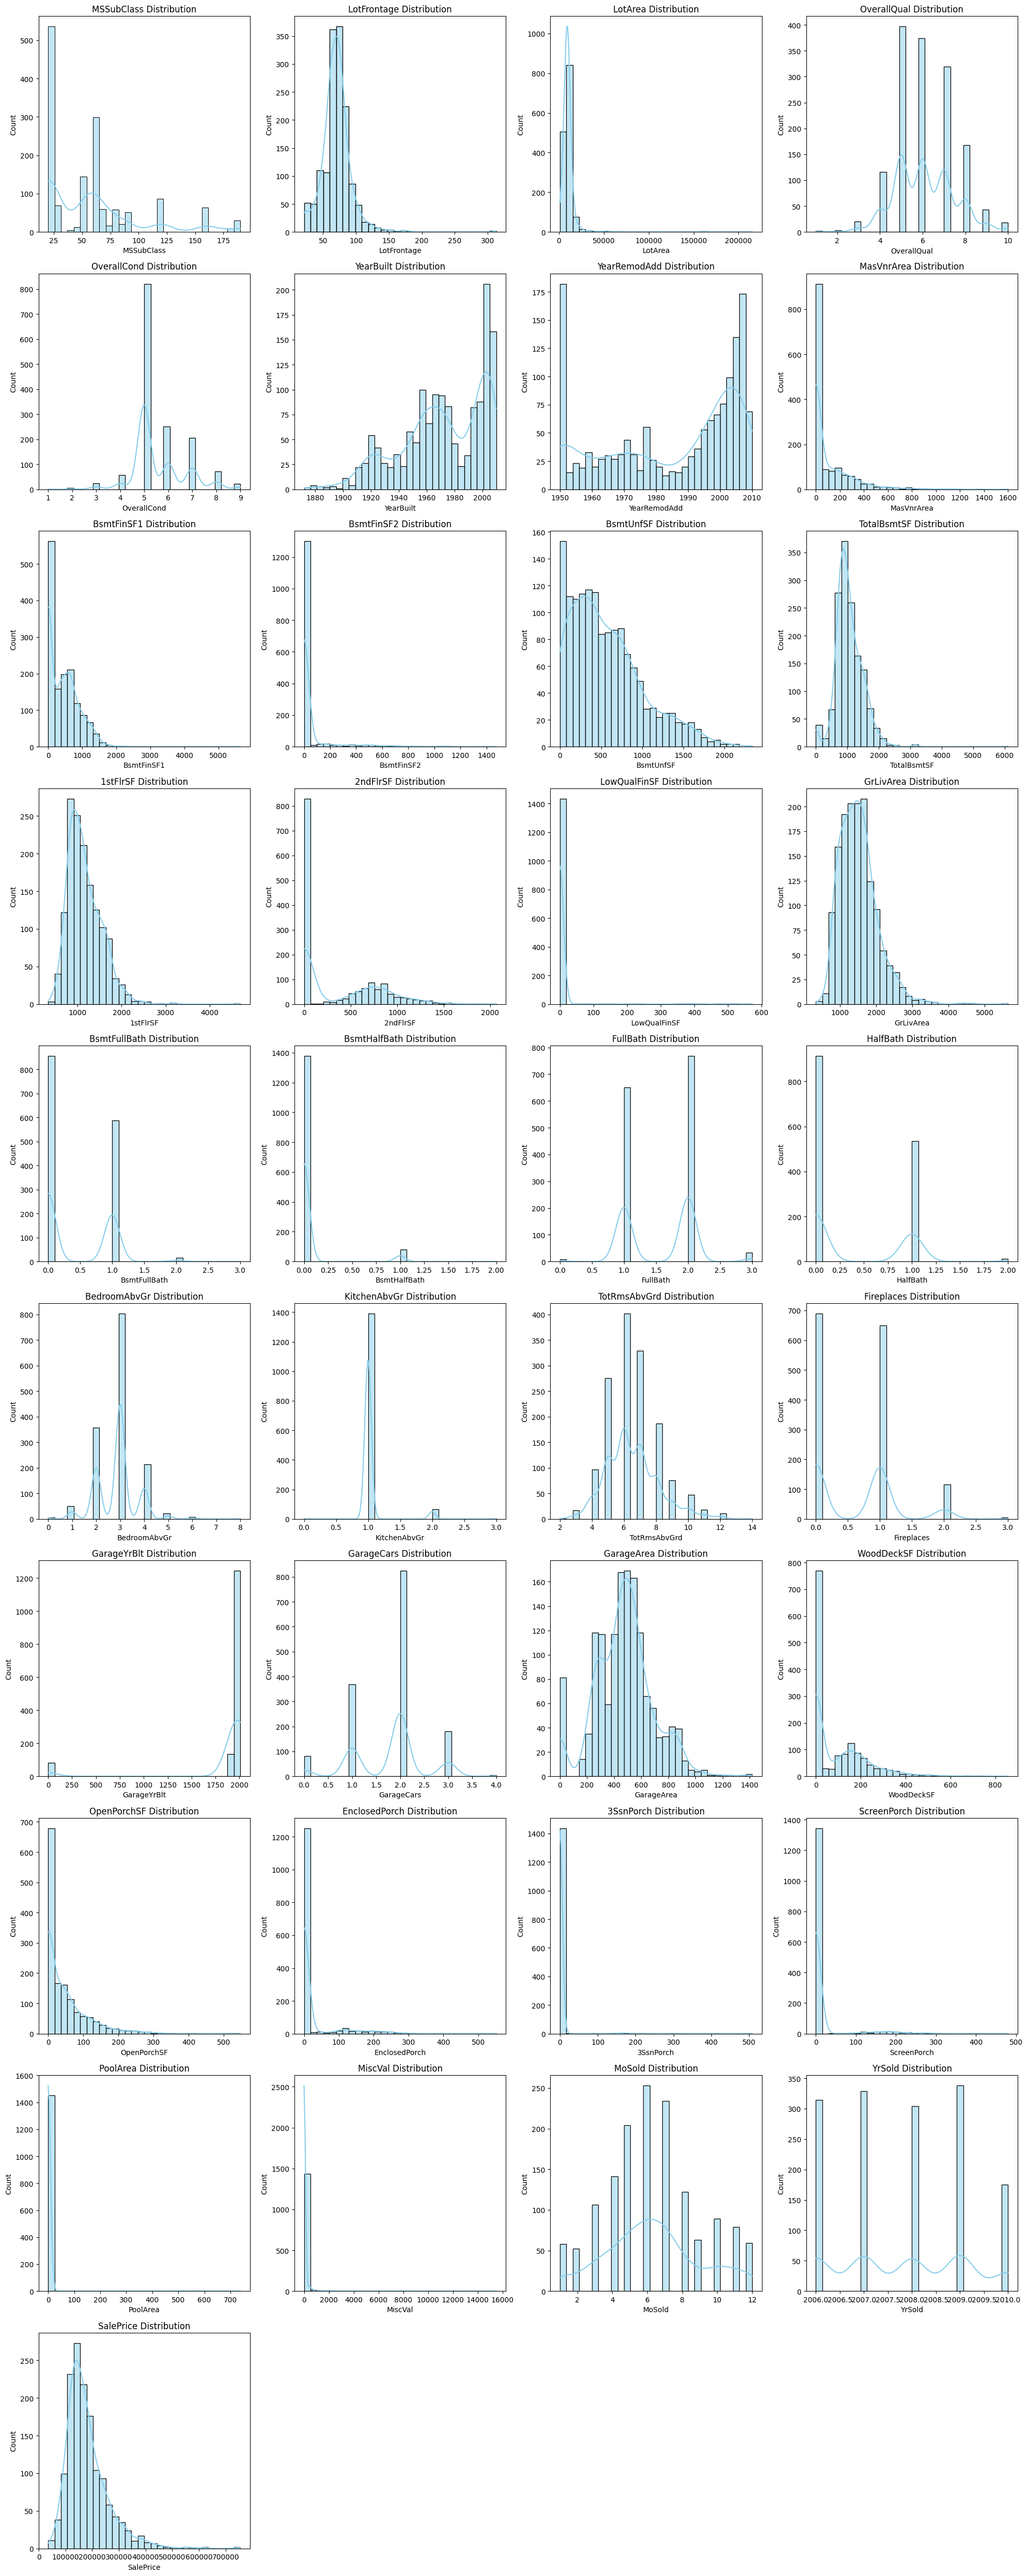

In [14]:
# numeric columns distribution
num_cols = train.select_dtypes(include=np.number).columns.tolist()
if 'Id' in num_cols:
    num_cols.remove('Id')

cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(train[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.tight_layout()

plt.show()

- Right-Skewed Distributions: LotArea, GrLivArea, TotalBsmtSF, 1stFlrSF, BsmtFinSF1, GarageArea, WoodDeckSF, OpenPorchSF, MasVnrArea, SalePrice
- Zero-Inflated: PoolArea, MiscVal, LowQualFinSF, 3SsnPorch, ScreenPorch, EnclosedPorch, BsmtFinSF2
- Normal Distributions: YearBuilt, YearRemodAdd, GarageYrBlt
- Discrete Distributions: OverallQual, OverallCond, BedroomAbvGr, KitchenAbvGr, Fireplaces, FullBath, HalfBath, BSmtFullBath, BsmtHalfBath, TotRmsAbvGrd, GarageCars
- Clustered + Right-Skewed: 2ndFlrSF, BsmtUnfSF, TotalSF, TotalPorch

In [265]:
# Check skewness and kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': train[num_cols].apply(lambda x: skew(x.dropna())),
    'Kurtosis': train[num_cols].apply(lambda x: kurtosis(x.dropna()))
}).sort_values(by='Skewness', ascending=False)

skew_kurt.head(30)

,Skewness,Kurtosis
MiscVal,24.451640,698.600840
PoolArea,14.813135,222.500507
LotArea,12.195142,202.543793
3SsnPorch,10.293752,123.235177
LowQualFinSF,9.002080,82.945932
KitchenAbvGr,4.483784,21.454627
BsmtFinSF2,4.250888,20.040415
ScreenPorch,4.117977,18.371874
BsmtHalfBath,4.099186,16.336436
EnclosedPorch,3.086696,10.390972


The skewness analysis revealed that several numerical variables exhibit strong right-skewness, particularly amenities that are rare in most homes such as PoolArea, 3SsnPorch, LowQualFinSF, and MiscVal. These features are zero-inflated and are better treated as binary indicators rather than continuous measures. Additionally, size-related variables such as TotalBsmtSF, 1stFlrSF, and GrLivArea are moderately skewed due to the presence of a small number of significantly large homes.

# Outlier handling

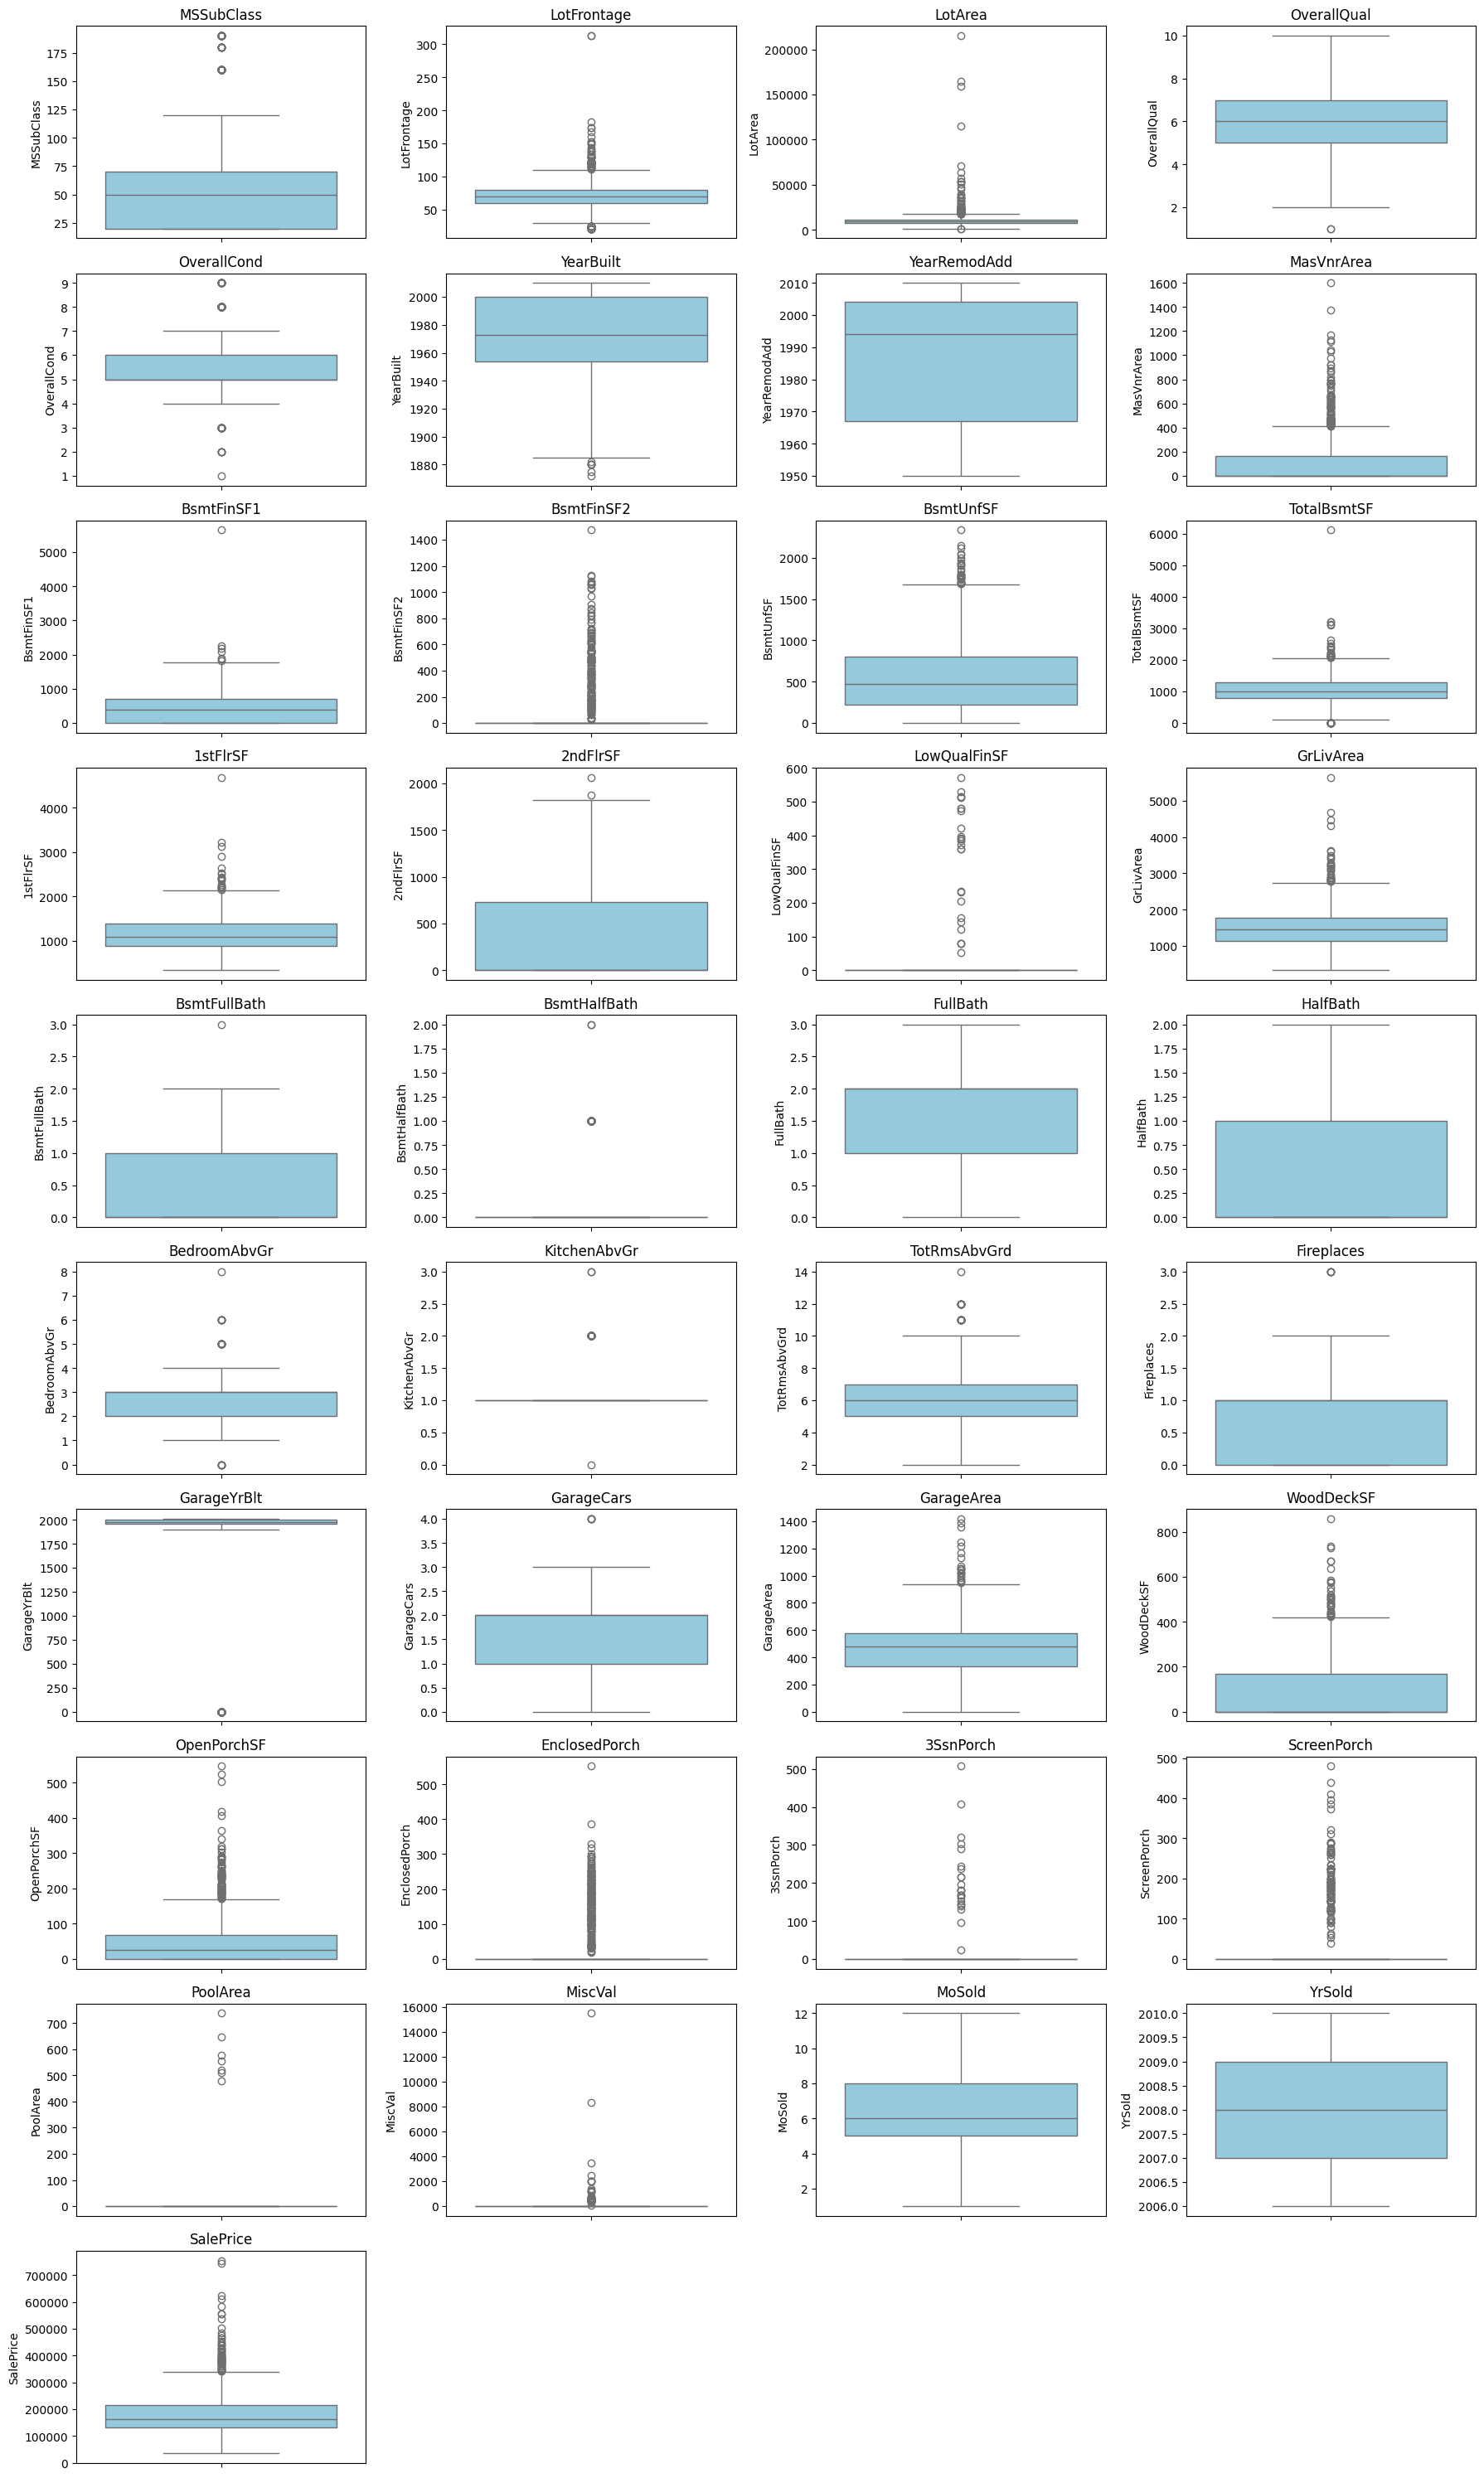

In [15]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()

# Remove Id
if "Id" in num_cols:
    num_cols.remove("Id")

cols = 4
rows = math.ceil(len(num_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
train = train.copy()
test = test.copy()

# Remove extreme case (GrLivArea)
if 'GrLivArea' in train.columns and 'SalePrice' in train.columns:
    before = train.shape[0]
    train = train.loc[~((train['GrLivArea'] > 4500) & (train['SalePrice'] < 700000))].copy()
    after = train.shape[0]
    print(f"GrLivArea rule removed {before-after} rows ({(before-after)/before:.2%})")

def ensure_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

iqr_cols = [
    'LotArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', 'GrLivArea', 'GarageArea', 'TotalSF'
]
iqr_cols = [c for c in iqr_cols if c in train.columns]
ensure_numeric(train, iqr_cols)
ensure_numeric(test, iqr_cols)

# IQR bounds
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

iqr_bounds = {}
for col in iqr_cols:
    lower, upper = get_iqr_bounds(train[col].dropna())
    if lower < 0 and train[col].min() >= 0:
        lower = 0.0
    iqr_bounds[col] = (lower, upper)

    before = train.shape[0]
    train = train.loc[(train[col] >= lower) & (train[col] <= upper)].copy()
    after = train.shape[0]
    print(f"{col}: Removed {before - after} rows ({(before-after)/before:.2%})")

for col, (lower, upper) in iqr_bounds.items():
    if col in test.columns:
        test[col] = pd.to_numeric(test[col], errors='coerce').fillna(lower)
        test[col] = test[col].clip(lower=lower, upper=upper)

# Winsorize
cap_cols = ['WoodDeckSF', 'OpenPorchSF', 'MasVnrArea', 'BsmtFinSF2']
cap_cols = [c for c in cap_cols if c in train.columns]

cap_values = {}
for col in cap_cols:
    upper_cap = train[col].quantile(0.99)
    cap_values[col] = upper_cap
    train[col] = np.where(train[col] > upper_cap, upper_cap, train[col])
    if col in test.columns:
        test[col] = pd.to_numeric(test[col], errors='coerce').fillna(0)
        test[col] = np.where(test[col] > upper_cap, upper_cap, test[col])

GrLivArea rule removed 2 rows (0.14%)
LotArea: Removed 66 rows (4.53%)
BsmtFinSF1: Removed 5 rows (0.36%)
BsmtUnfSF: Removed 30 rows (2.16%)
TotalBsmtSF: Removed 53 rows (3.91%)
1stFlrSF: Removed 6 rows (0.46%)
GrLivArea: Removed 26 rows (2.00%)
GarageArea: Removed 6 rows (0.47%)


Outliers were examined visually using boxplots and assessed statistically using the Interquartile Range (IQR) method. Several continuous variables displayed strong right-skew and extreme high values, particularly those related to property size such as LotArea, BsmtFinSF1, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, GrLivArea, GarageArea, and the engineered TotalSF feature. Because extreme values in these features can distort model training and inflate error, we removed outliers falling beyond 1.5 × IQR for these variables. Additionally, we removed unusually large homes with very low sale prices in the GrLivArea feature. For variables with many zeros and a few extremely large values (e.g., MasVnrArea, WoodDeckSF, OpenPorchSF, BsmtFinSF2), we capped extreme values at the 99th percentile instead of removing observations, in order to preserve dataset size and maintain underlying distribution patterns. Overall, this balanced strategy ensures that the dataset remains representative while reducing the influence of extreme, non-typical values on model performance.

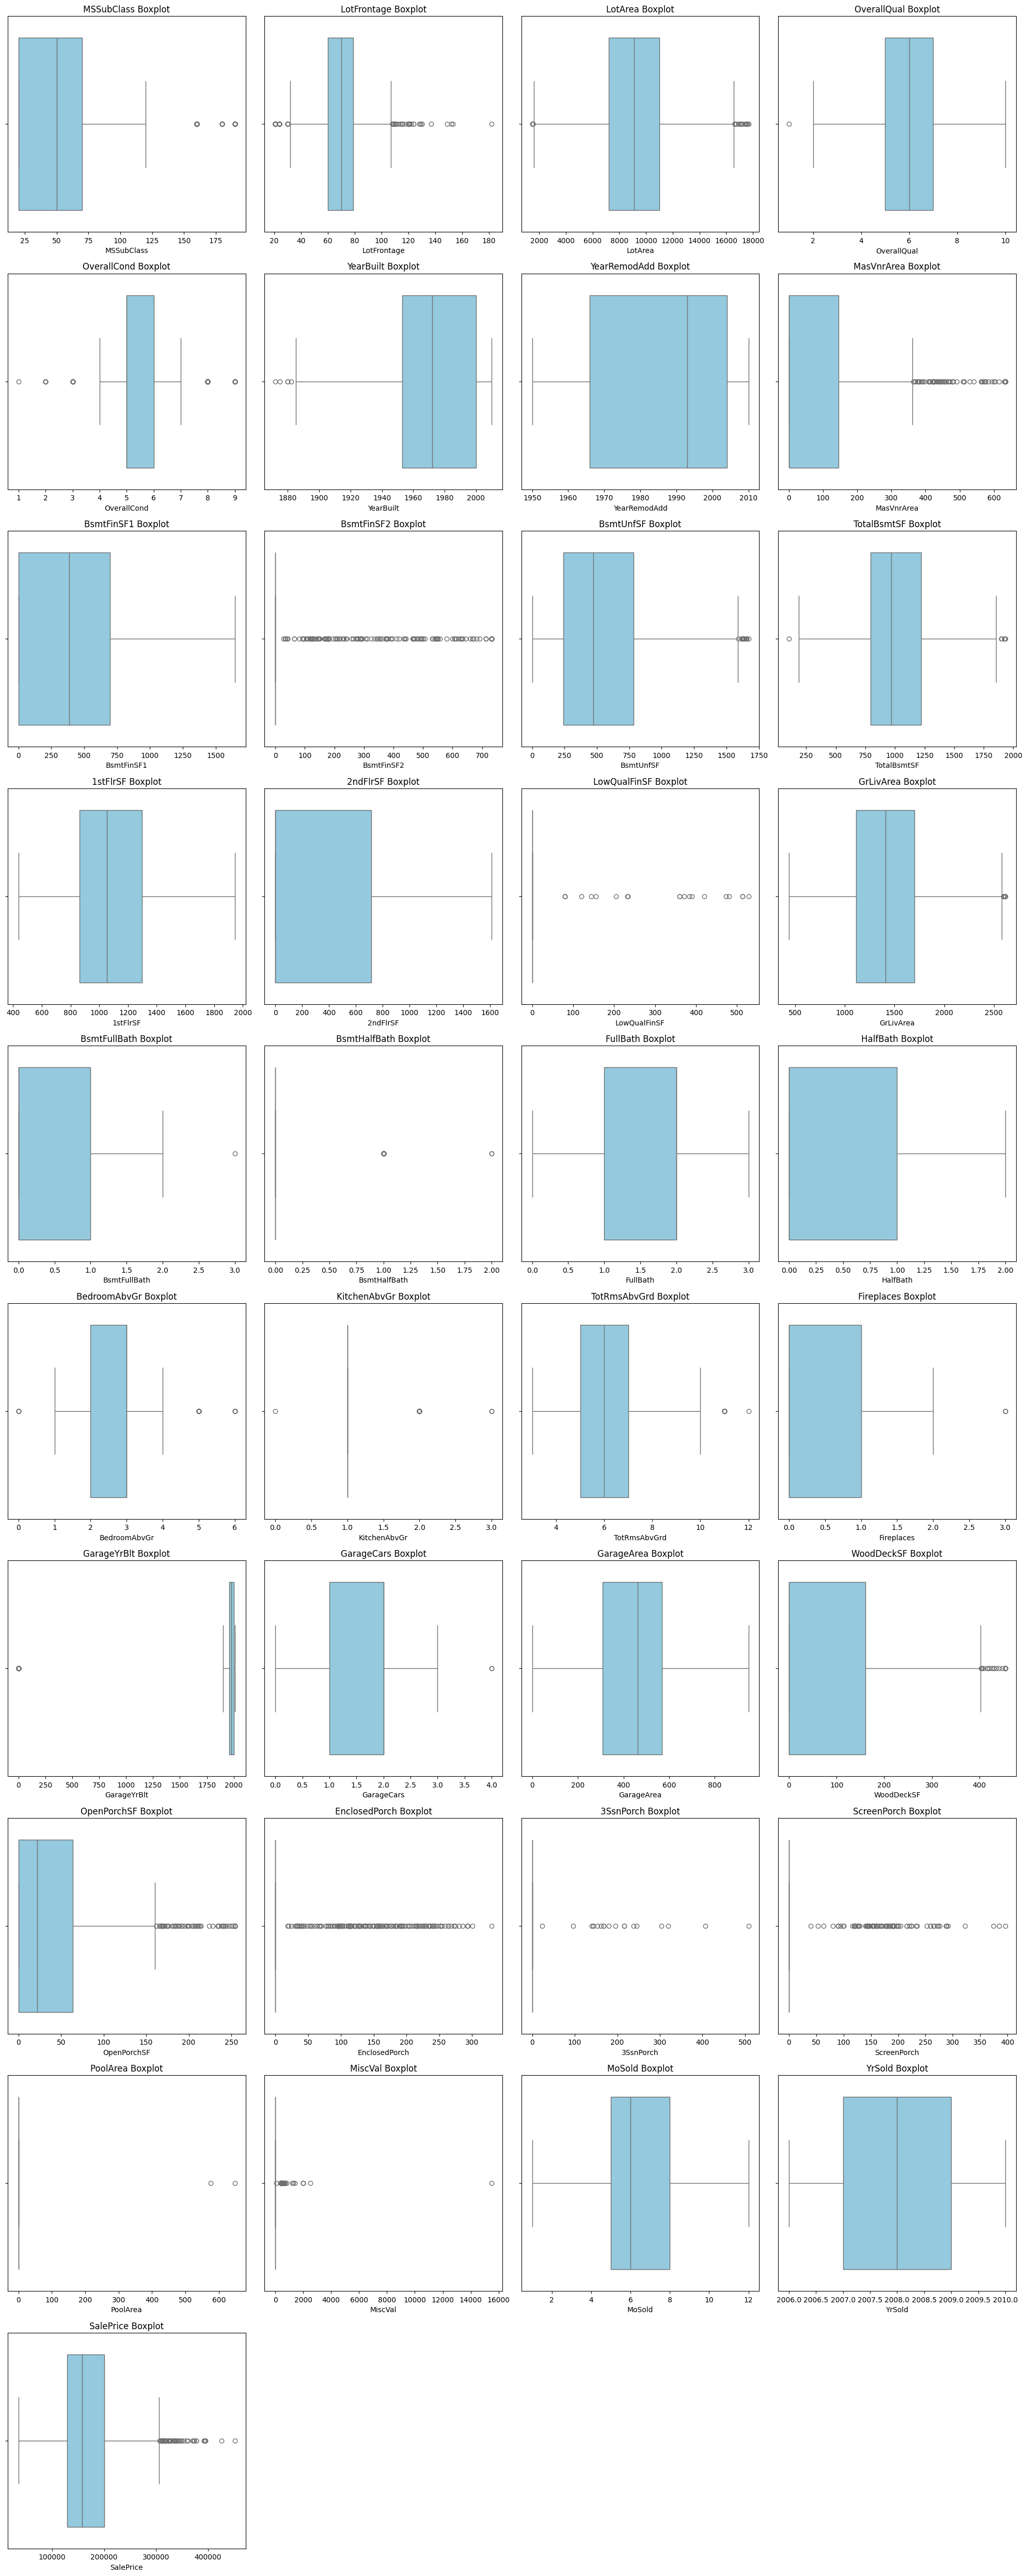

In [17]:
# boxplots after outlier handling
num_cols = train.select_dtypes(include=np.number).columns.tolist()

if "Id" in num_cols:
    num_cols.remove("Id")
    
cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=train[col], color="skyblue")
    plt.title(f"{col} Boxplot")
    plt.tight_layout()

plt.show()

## Biveriate analysis

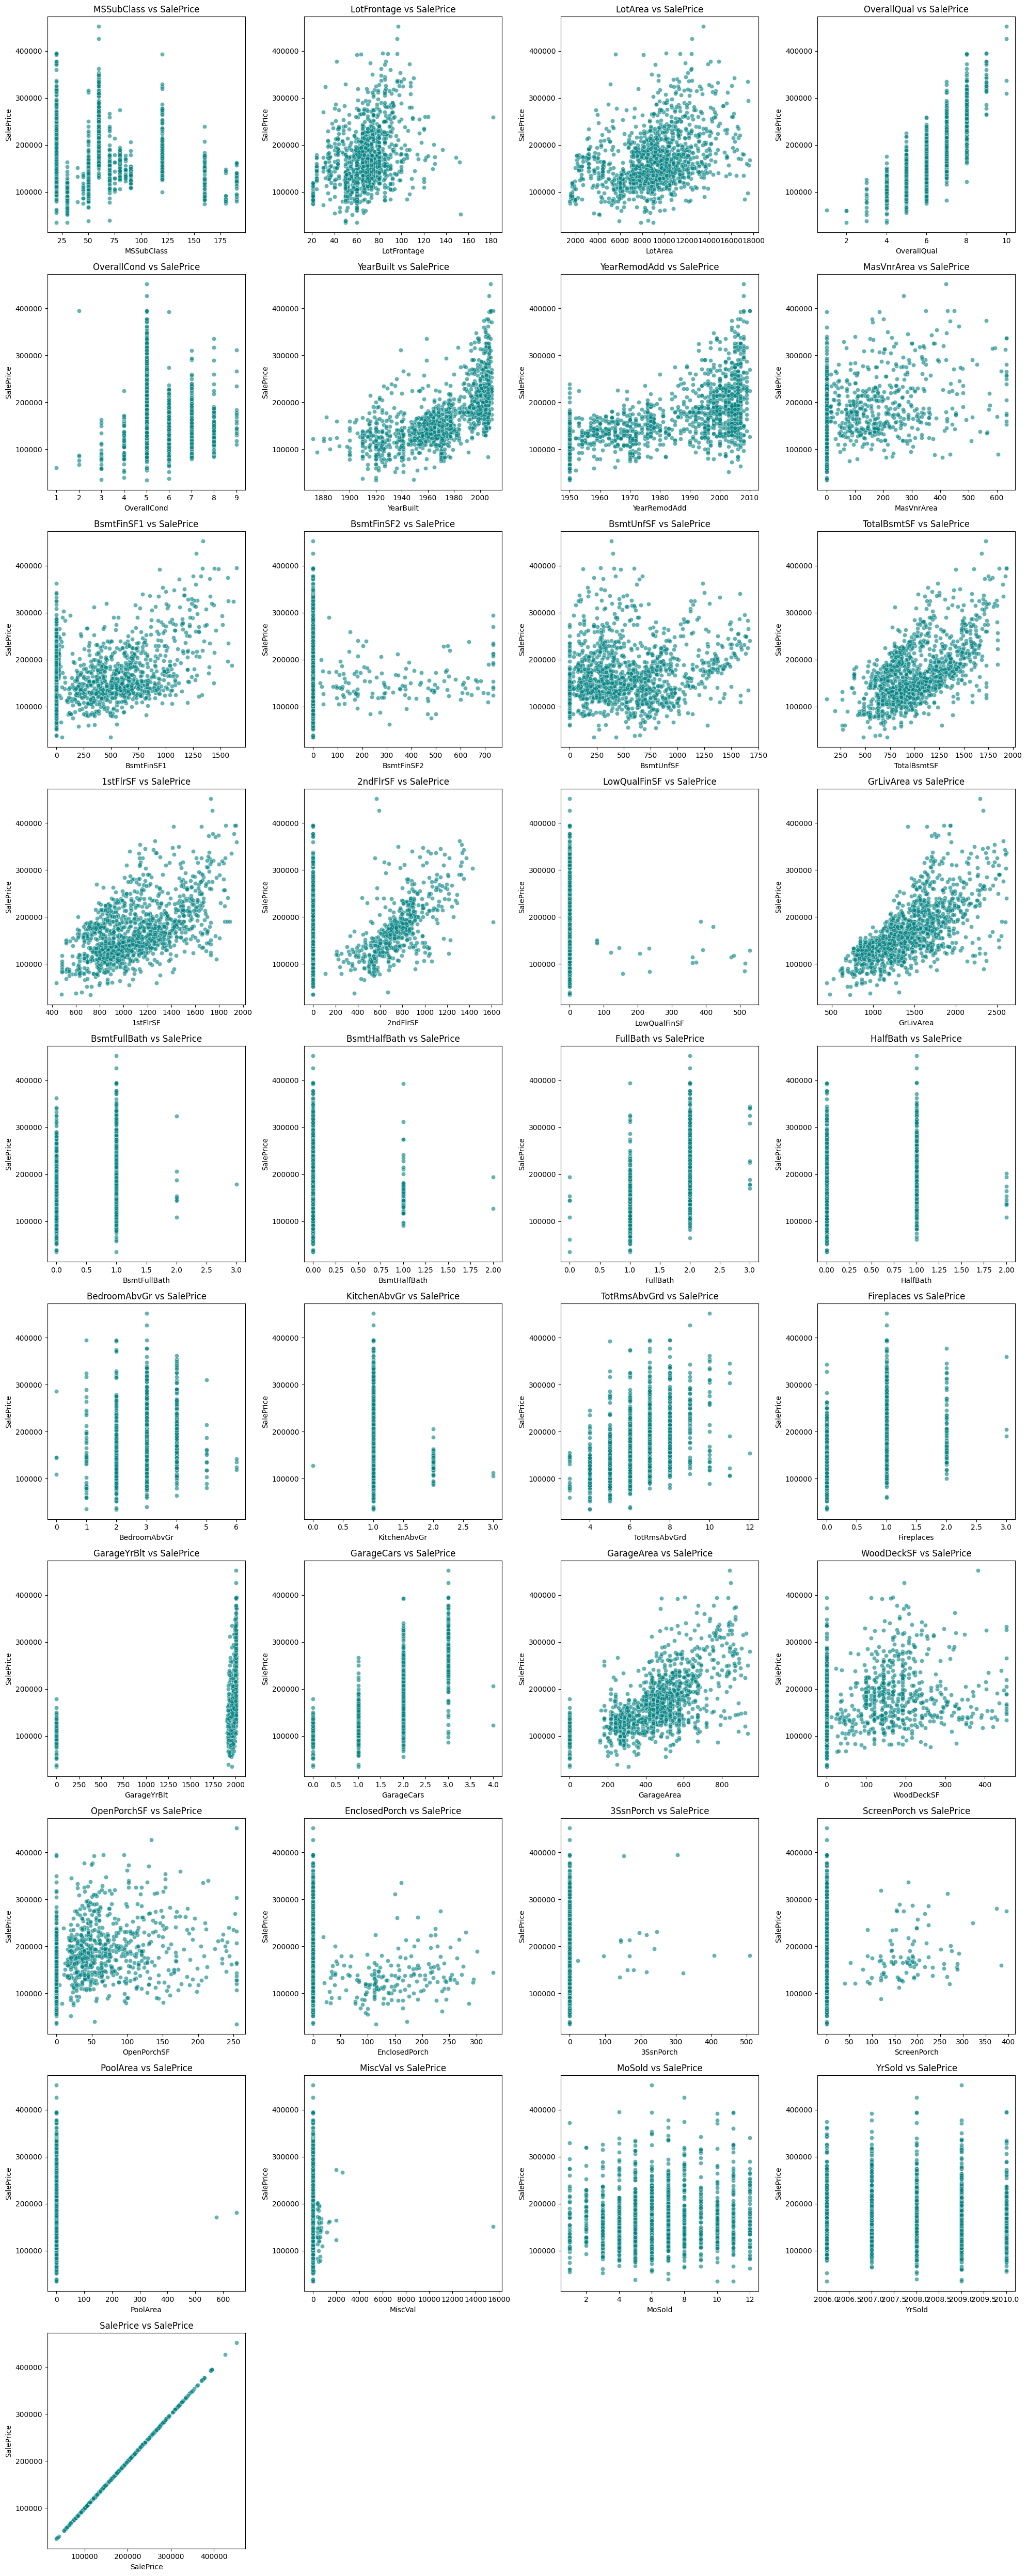

In [18]:
# Numerical vs Target
cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.scatterplot(data=train, x=col, y='SalePrice', color='teal', alpha=0.6)
    plt.title(f'{col} vs SalePrice')
plt.tight_layout()
plt.show()

The scatterplots show that several numeric features have a clear linear relationship with SalePrice, especially size-related variables such as GrLivArea, TotalBsmtSF, 1stFlrSF, and GarageArea. These features display upward-sloping patterns, meaning larger homes consistently sell for higher prices. Quality indicators like OverallQual also show strong positive trends, reinforcing that better-quality houses attract higher prices. In contrast, smaller or rarely occurring features—such as MiscVal, LowQualFinSF, or 3SsnPorch—show little to no linear pattern with SalePrice, indicating minimal predictive value. Overall, size and quality remain the strongest linear drivers of property prices.

The bivariate analysis of categorical features against SalePrice highlights several patterns in how structural quality, location, and property characteristics influence home values. Neighborhood stands out as one of the strongest categorical predictors of price, with certain areas such as *StoneBr*, *NridgHt*, and *NoRidge* consistently associated with significantly higher sale prices. This suggests a clear location-based premium in the housing market. Conversely, neighborhoods like *MeadowV* and *IDOTRR* show noticeably lower price ranges, indicating market segmentation by locality.

Quality-related categorical variables also show meaningful gradients. For instance, homes with higher KitchenQual and ExterQual ratings show higher SalePrice distributions. This supports the pattern observed earlier that material and finish quality strongly influence perceived and market value. Similarly, BsmtQual and GarageQual show a positive association with price, although the effect is less pronounced than for above-ground quality indicators.

Some categorical variables showed limited or no variation in relation to SalePrice. For example, Utilities and Street show almost no discriminatory power because nearly all homes share the same category. These features offer little value and can be removed to simplify the model without information loss. RoofStyle, Heating type, and Functional categories also showed only weak price differentiation, suggesting these features carry less predictive weight.

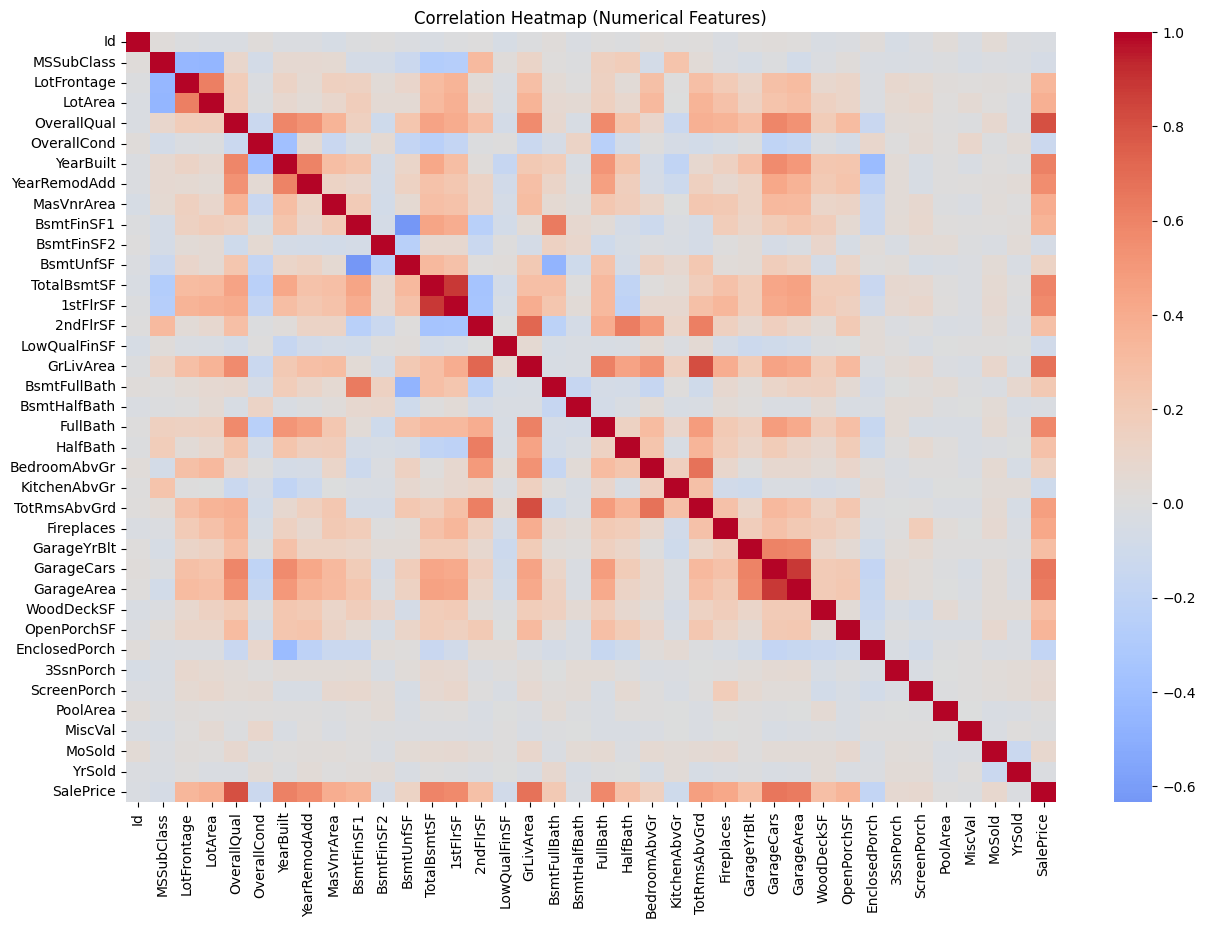

In [19]:
# correlation matrix
corr = train.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

In [20]:
corr.SalePrice.sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.802557
GrLivArea        0.675159
GarageCars       0.656674
GarageArea       0.631551
YearBuilt        0.612143
TotalBsmtSF      0.595117
FullBath         0.583877
1stFlrSF         0.566400
YearRemodAdd     0.555147
TotRmsAbvGrd     0.471698
Fireplaces       0.425236
MasVnrArea       0.394790
LotArea          0.377426
BsmtFinSF1       0.358776
OpenPorchSF      0.345428
LotFrontage      0.336315
GarageYrBlt      0.296604
WoodDeckSF       0.291412
2ndFlrSF         0.275339
HalfBath         0.267893
BsmtFullBath     0.217331
BedroomAbvGr     0.156169
BsmtUnfSF        0.130781
MoSold           0.081968
ScreenPorch      0.079173
3SsnPorch        0.067937
PoolArea         0.004157
MiscVal         -0.013144
YrSold          -0.020926
Id              -0.023199
BsmtHalfBath    -0.026285
MSSubClass      -0.055695
BsmtFinSF2      -0.057522
LowQualFinSF    -0.087525
KitchenAbvGr    -0.110197
OverallCond     -0.123500
EnclosedPorch   -0.181776
Name: SalePr

The correlation analysis shows that house quality and size are the strongest drivers of sale price. OverallQual has the highest positive correlation with SalePrice, followed by GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and YearBuilt/YearRemodAdd, indicating that larger homes with better construction and more recent updates tend to sell for higher prices. Features such as KitchenAbvGr, LowQualFinSF, and EnclosedPorch show weak or negative correlations, suggesting they contribute little to price variation and may be less important in modeling. Additionally, several size-related features are strongly correlated with one another.

## Multivariate analysis

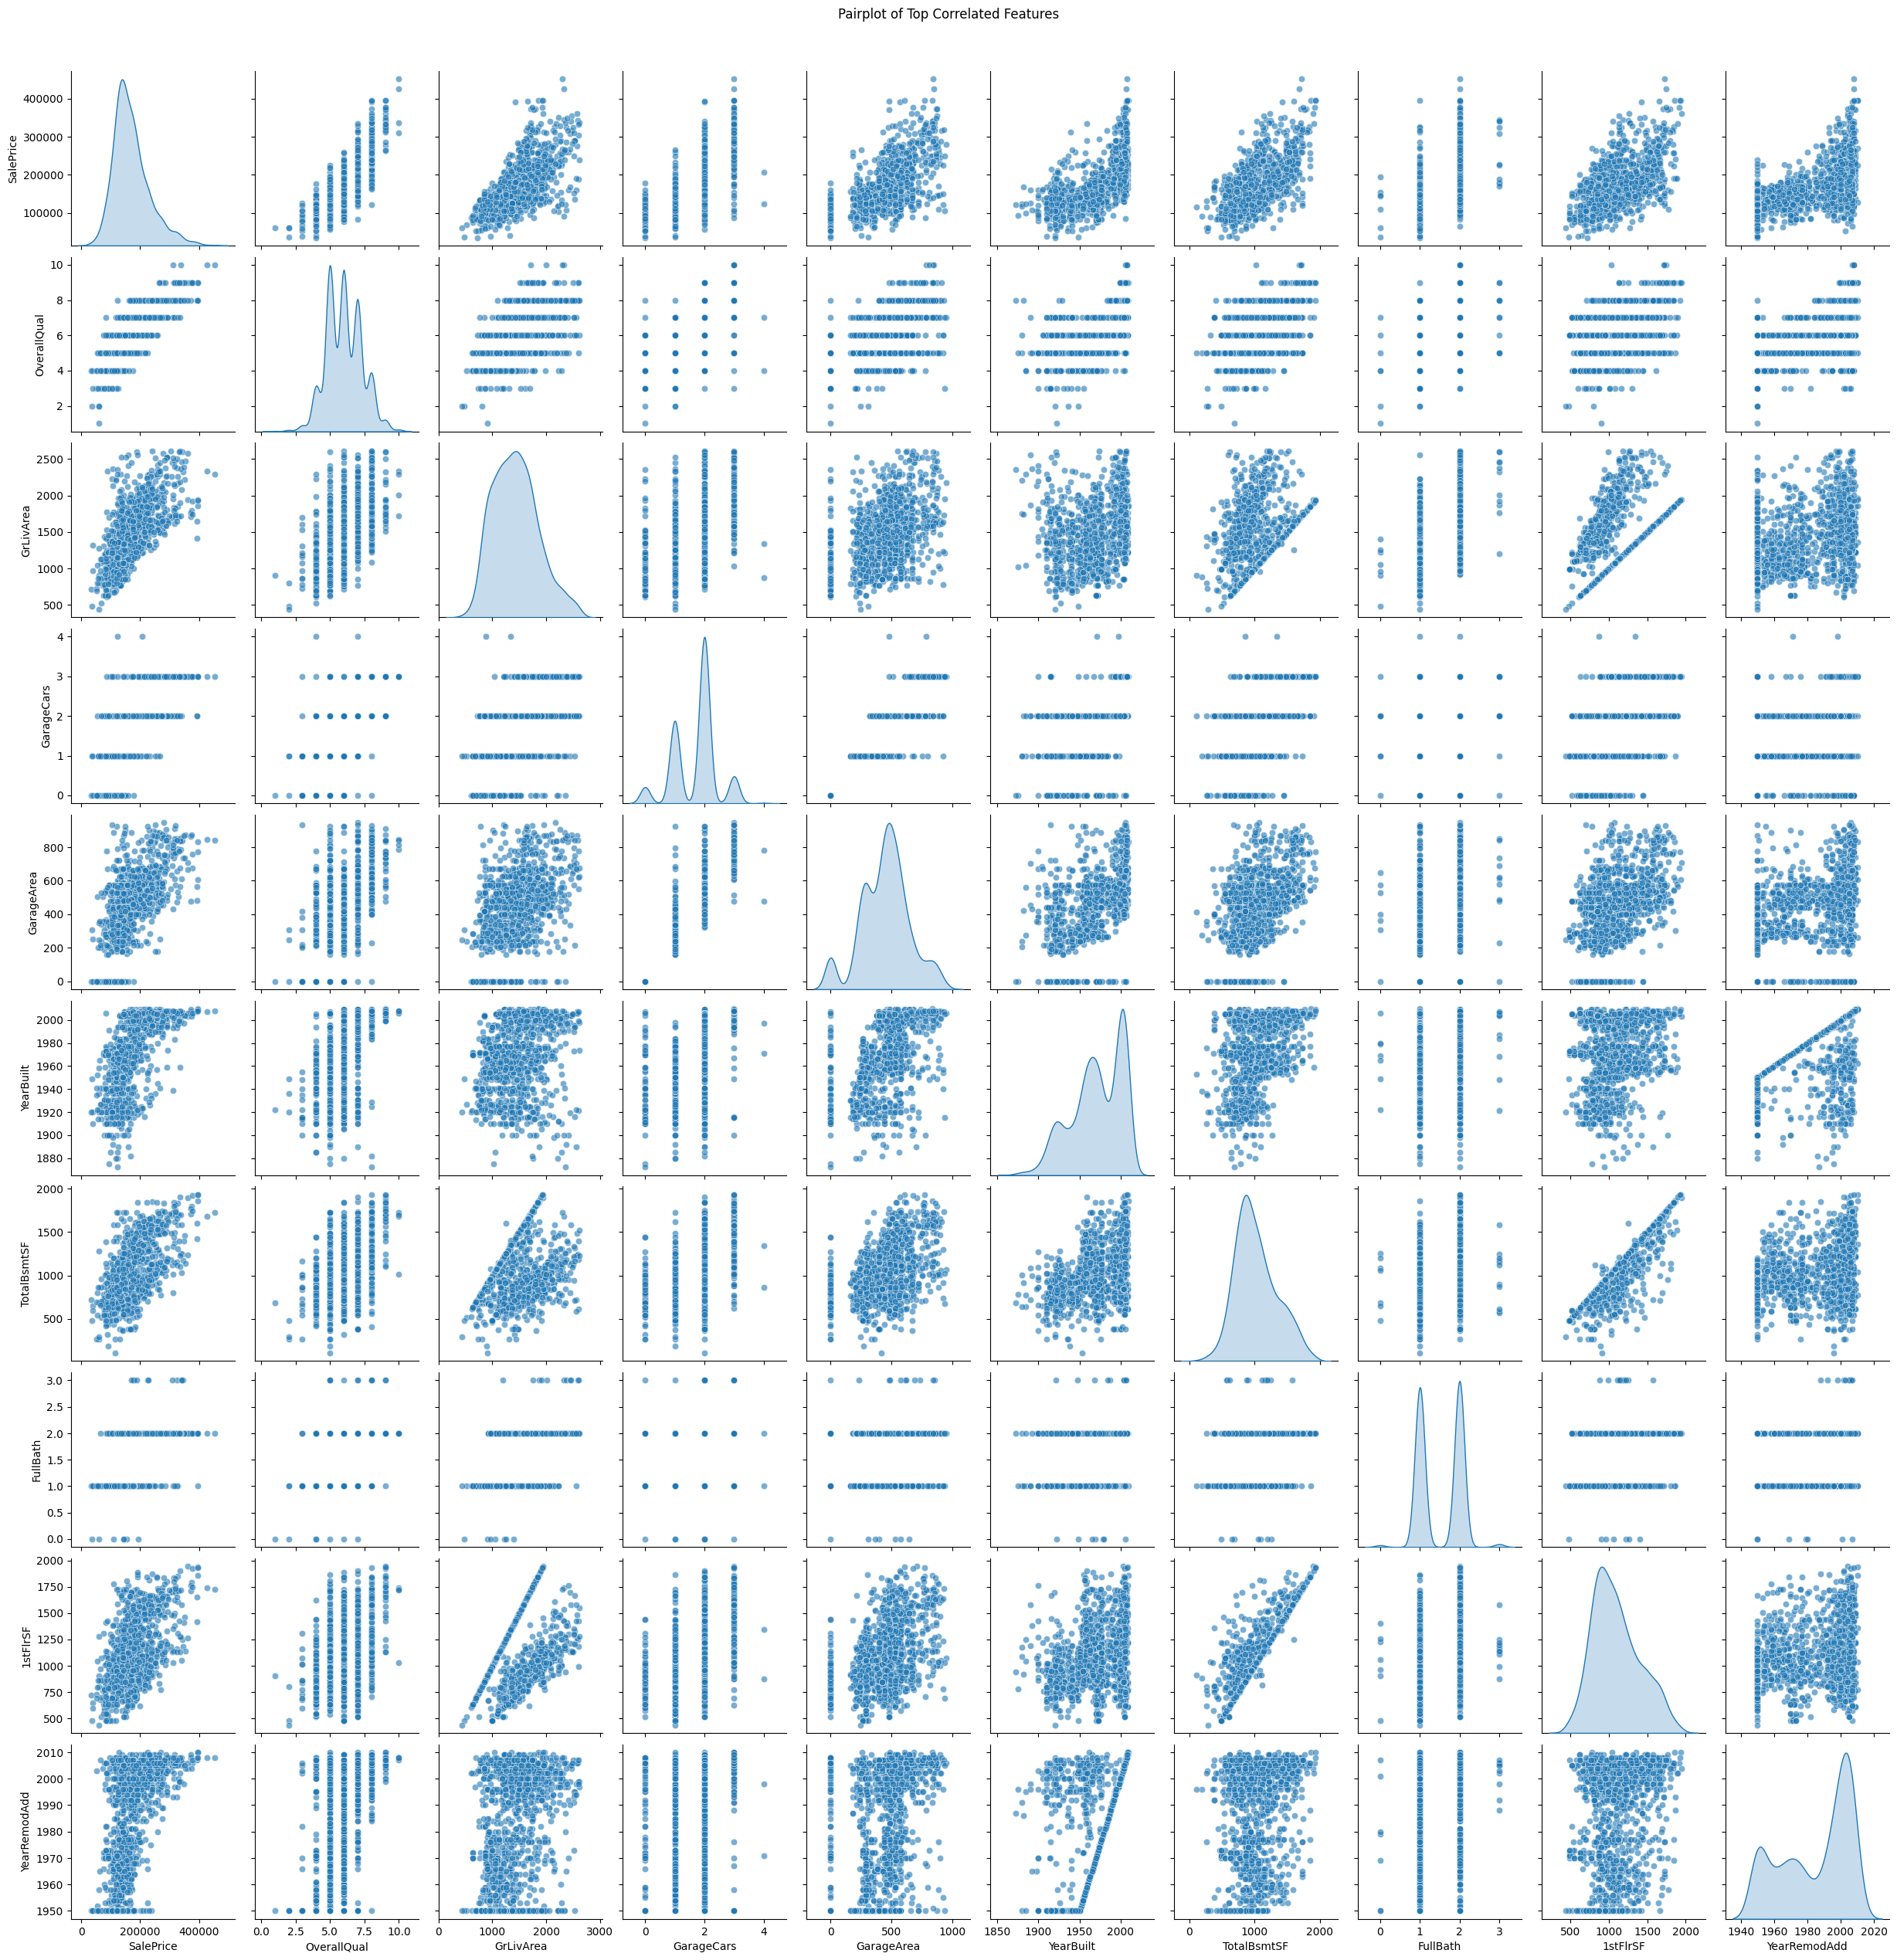

In [23]:
# Pairplot for top correlated numeric variables
corr_matrix = train.corr(numeric_only=True)

top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(10).index

sns.pairplot(train[top_corr], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Top Correlated Features', y=1.02)
plt.show()

The pairplot highlights the strongest relationships between the top correlated features and SalePrice. Size-related features like GrLivArea, GarageArea, and GarageCars show clear positive upward trends—larger living spaces and bigger garages consistently correspond to higher sale prices. OverallQual displays one of the strongest patterns, with prices rising sharply as quality improves. FullBath also shows a mild positive association, reflecting the added value of more bathrooms. The density plots on the diagonal further show well-distributed continuous features and more discrete patterns in categorical-like variables. Overall, the pairplot confirms that home size and quality are the most influential drivers of price.

In [24]:
# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = train[['TotalBsmtSF','GrLivArea','GarageCars','GarageArea','OverallQual','YearBuilt']].assign(const=1)
vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif

,Feature,VIF
0,TotalBsmtSF,1.402952
1,GrLivArea,1.610487
2,GarageCars,5.328207
3,GarageArea,4.760433
4,OverallQual,2.361626
5,YearBuilt,1.874065
6,const,7291.735217


The VIF results show that multicollinearity is generally low indicating that these predictors provide mostly independent information to the model. They remain within acceptable limits and are safe to keep. Overall, multicollinearity is not a concern in the dataset.

## Encoding

In [25]:
# ordinal
quality_map = {"Ex":5,"Gd":4,"TA":3,"Fa":2,"Po":1,"None":0}
bsmt_exposure_map = {"Gd":4,"Av":3,"Mn":2,"No":1,"None":0}
bsmt_fin_map = {"GLQ":6,"ALQ":5,"BLQ":4,"Rec":3,"LwQ":2,"Unf":1,"None":0}
functional_map = {"Typ":7,"Min1":6,"Min2":5,"Mod":4,"Maj1":3,"Maj2":2,"Sev":1,"Sal":0}
paved_map = {"Y":2,"P":1,"N":0}
fence_map = {"GdPrv":4,"MnPrv":3,"GdWo":2,"MnWw":1,"None":0}
pool_map = {"Ex":4,"Gd":3,"TA":2,"Fa":1,"None":0}
garage_finish_map = {"Fin":3,"RFn":2,"Unf":1,"None":0}
garage_qual_map = {"Ex":5,"Gd":4,"TA":3,"Fa":2,"Po":1,"None":0}

feature_maps = {
    "ExterQual": quality_map,
    "ExterCond": quality_map,
    "HeatingQC": quality_map,
    "KitchenQual": quality_map,
    "FireplaceQu": quality_map,

    "BsmtQual": quality_map,
    "BsmtCond": quality_map,
    "BsmtExposure": bsmt_exposure_map,
    "BsmtFinType1": bsmt_fin_map,
    "BsmtFinType2": bsmt_fin_map,

    "GarageQual": garage_qual_map,
    "GarageCond": garage_qual_map,
    "GarageFinish": garage_finish_map,

    "Functional": functional_map,
    "PavedDrive": paved_map,
    "Fence": fence_map,
    "PoolQC": pool_map
}

def apply_feature_maps(df, feature_maps):
    df = df.copy()
    for col, mp in feature_maps.items():
        if col in df.columns:
            df[col] = df[col].fillna("None").astype(str)
            df[col] = df[col].map(lambda v: mp.get(v, 0)).astype(int)
    return df

train = apply_feature_maps(train, feature_maps)
test  = apply_feature_maps(test, feature_maps)

In [26]:
# One-Hot Encoding
one_hot_features = [
    "MSZoning", "LandContour", "LotConfig", "Neighborhood", "Condition1",
    "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating",
    "CentralAir", "Electrical", "GarageType", "MiscFeature", "SaleType",
    "SaleCondition", "Street", "Utilities", "LotShape", "LandSlope", "Alley"
]

one_hot_features = [col for col in one_hot_features if col in train.columns or col in test.columns]

combined = pd.concat([train, test], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=one_hot_features, drop_first=True)

train = combined.iloc[:len(train)].copy()
test  = combined.iloc[len(train):].copy()

In [27]:
if 'SalePrice' in test.columns:
    test = test.drop(columns=['SalePrice'])

train_feat_cols = [c for c in train.columns if c != 'SalePrice']

test = test.reindex(columns=train_feat_cols, fill_value=0)

if 'Id' in test.columns and 'Id' not in train_feat_cols:
    test_ids = test['Id'].copy()
    test = test.drop(columns=['Id'])

# Feature engineering

In [28]:
# 1. Total Square Footage
train['TotalSF'] = (
    train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
)

test['TotalSF'] = (
    test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
)

# 2. Total Bathrooms
train['Total_Bathrooms'] = (
    train['FullBath'] 
    + 0.5 * train['HalfBath']
    + train['BsmtFullBath']
    + 0.5 * train['BsmtHalfBath']
)

test['Total_Bathrooms'] = (
    test['FullBath'] 
    + 0.5 * test['HalfBath']
    + test['BsmtFullBath']
    + 0.5 * test['BsmtHalfBath']
)

# 3. House Age Features
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

# 4. Quality × Size Interaction
train['OverallQualArea'] = train['OverallQual'] * train['TotalSF']
test['OverallQualArea'] = test['OverallQual'] * test['TotalSF']

train['QualityScore'] = train['OverallQual'] * train['OverallCond']
test['QualityScore'] = test['OverallQual'] * test['OverallCond']

# 5. Total Porch Area
train['TotalPorch'] = (
    train['OpenPorchSF'] + train['EnclosedPorch'] +
    train['ScreenPorch'] + train['3SsnPorch']
)

test['TotalPorch'] = (
    test['OpenPorchSF'] + test['EnclosedPorch'] +
    test['ScreenPorch'] + test['3SsnPorch']
)

In [29]:
print("Train:", train.shape)
print("Test:", test.shape)

Train: (1266, 207)
Test: (1459, 206)


# Train-test split

In [30]:
y = train["SalePrice"]
X = train.drop(["SalePrice", "Id"], axis=1)
test_ids = test["Id"]
X_test = test.drop(["Id"], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", test.shape)

X_train: (1012, 205)
X_val:   (254, 205)
X_test:  (1459, 206)


# Model training

In [31]:
# Linear regression
pipe_lr = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1),
    LinearRegression()
)

scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring="r2")
print("Linear Regression R2 Scores:", scores_lr)
print("Mean R2:", scores_lr.mean(), "\n")

Linear Regression R2 Scores: [0.92052722 0.91522783 0.92285294 0.89128059 0.90605697]
Mean R2: 0.9111891082882689 



In [32]:
# Lasso Regression
pipe_lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.001, max_iter=100000, random_state=42)
)

scores_lasso = cross_val_score(pipe_lasso, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
print("Lasso R2 Scores:", scores_lasso)
print("Mean R2:", scores_lasso.mean())

Lasso R2 Scores: [0.92034976 0.91519579 0.9232417  0.89131298 0.90569674]
Mean R2: 0.9111593928139369


In [33]:
# Ridge Regression
pipe_ridge = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1),
    Ridge(alpha=1.0, random_state=42)
)

scores_ridge = cross_val_score(pipe_ridge, X_train, y_train, cv=5, scoring="r2")
print("Ridge R2 Scores:", scores_ridge)
print("Mean R2:", scores_ridge.mean())

Ridge R2 Scores: [0.9195258  0.91386686 0.91717184 0.89569167 0.90736284]
Mean R2: 0.9107238005151709


In [34]:
# ElasticNet Regression
pipe_enet = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1),
    ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=20000, random_state=42)
)

scores_enet = cross_val_score(pipe_enet, X_train, y_train, cv=5, scoring="r2")
print("ElasticNet R2 Scores:", scores_enet)
print("Mean R2:", scores_enet.mean())

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.067e+10, tolerance: 3.011e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.192e+10, tolerance: 3.000e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

ElasticNet R2 Scores: [0.92055078 0.91526092 0.92141123 0.89298994 0.90675016]
Mean R2: 0.9113926068636224


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.759e+10, tolerance: 2.990e+08
  model = cd_fast.enet_coordinate_descent(


In [35]:
# Random forest
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("RandomForest R² scores:", rf_scores)
print("Mean R²:", rf_scores.mean())

RandomForest R² scores: [0.9045802  0.91233598 0.90976986 0.8949487  0.87774855]
Mean R²: 0.8998766585287512


In [36]:
# Gradient boosting
gbr = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gbr_scores = cross_val_score(gbr, X_train, y_train, cv=5, scoring='r2')
print("GradientBoosting R² scores:", gbr_scores)
print("Mean R²:", gbr_scores.mean())

GradientBoosting R² scores: [0.91841015 0.91719434 0.91582843 0.90483868 0.898941  ]
Mean R²: 0.9110425177042215


In [37]:
# XG Boost
xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
print("XGBoost R² scores:", xgb_scores)
print("Mean R²:", xgb_scores.mean())

XGBoost R² scores: [0.91818388 0.92668104 0.91896716 0.91122066 0.90837817]
Mean R²: 0.91668617935466


Linear Regression, Lasso, Ridge, and ElasticNet all performed similarly with R² scores around 0.91, showing that the data follows mostly linear patterns. Among them, Ridge Regression was the most stable across folds because it handles correlated features better. I also tested Random Forest, Gradient boosting, and XGBoost, and found that XGBoost performed the best overall, but Ridge was chosen as the main linear model due to its balance of accuracy, stability, and interpretability.

## Hyperparameter Optimization

In [ ]:
# Hyperparameter Grid
param_grid = {
    "alpha": [0.1, 1, 5, 10, 20, 50, 100]
}

ridge = Ridge(random_state=42)

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit the model
grid.fit(X_train, y_train)

print("Best Ridge alpha:", grid.best_params_["alpha"])
print("Best CV R²:", grid.best_score_)

# 3. Evaluate
best_ridge = grid.best_estimator_

# Predict on validation set
y_val_pred = best_ridge.predict(X_val)

r2 = best_ridge.score(X_val, y_val)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Validation R²:  {r2:.4f}")
print(f"Validation RMSE: {rmse:.4f}")

Best Ridge alpha: 10
Best CV R²: 0.921460163480095
Validation R²:  0.9053
Validation RMSE: 18722.5053


The Ridge model with α = 10 provided the best balance between bias and variance. It achieved a cross-validated R² of 0.921, confirming strong generalization during training. On the held-out validation set, the model maintained a high R² of 0.905, with an RMSE of $18.7K, meaning predictions deviate from actual prices by about $19K on average. Considering model stability, consistent performance, and the fact that the target was not log-transformed, Ridge delivered the most reliable and interpretable linear baseline among all tested models.

## Validation & learning curve

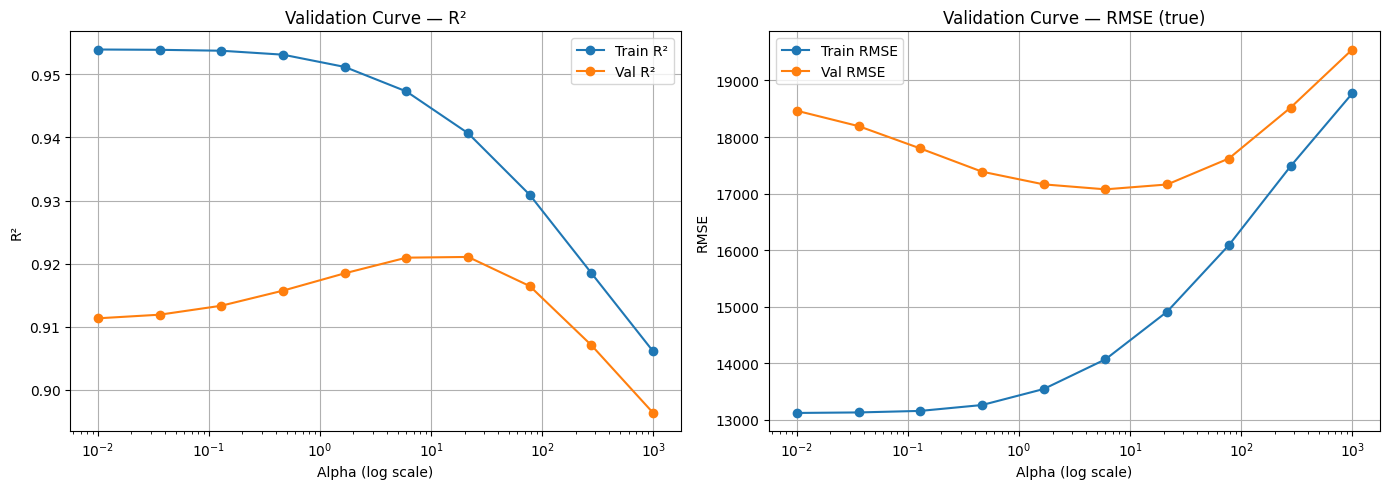

In [ ]:
# ALPHAS
alphas = np.logspace(-2, 3, 10)

# R²
train_scores_r2, val_scores_r2 = validation_curve(
    Ridge(),
    X_train, y_train,
    param_name="alpha",
    param_range=alphas,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

train_r2_mean = train_scores_r2.mean(axis=1)
val_r2_mean = val_scores_r2.mean(axis=1)

# RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_rmse_means = []
val_rmse_means = []

for a in alphas:
    train_rmse_folds = []
    val_rmse_folds = []
    model = Ridge(alpha=a)

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_tr_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_val)

        train_rmse_folds.append(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))
        val_rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

    train_rmse_means.append(np.mean(train_rmse_folds))
    val_rmse_means.append(np.mean(val_rmse_folds))

# Plot R² and RMSE
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² curves
axes[0].semilogx(alphas, train_r2_mean, marker='o', label='Train R²')
axes[0].semilogx(alphas, val_r2_mean, marker='o', label='Val R²')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R²')
axes[0].set_title('Validation Curve — R²')
axes[0].legend()
axes[0].grid(True)

# RMSE curves
axes[1].semilogx(alphas, train_rmse_means, marker='o', label='Train RMSE')
axes[1].semilogx(alphas, val_rmse_means, marker='o', label='Val RMSE')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Validation Curve — RMSE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

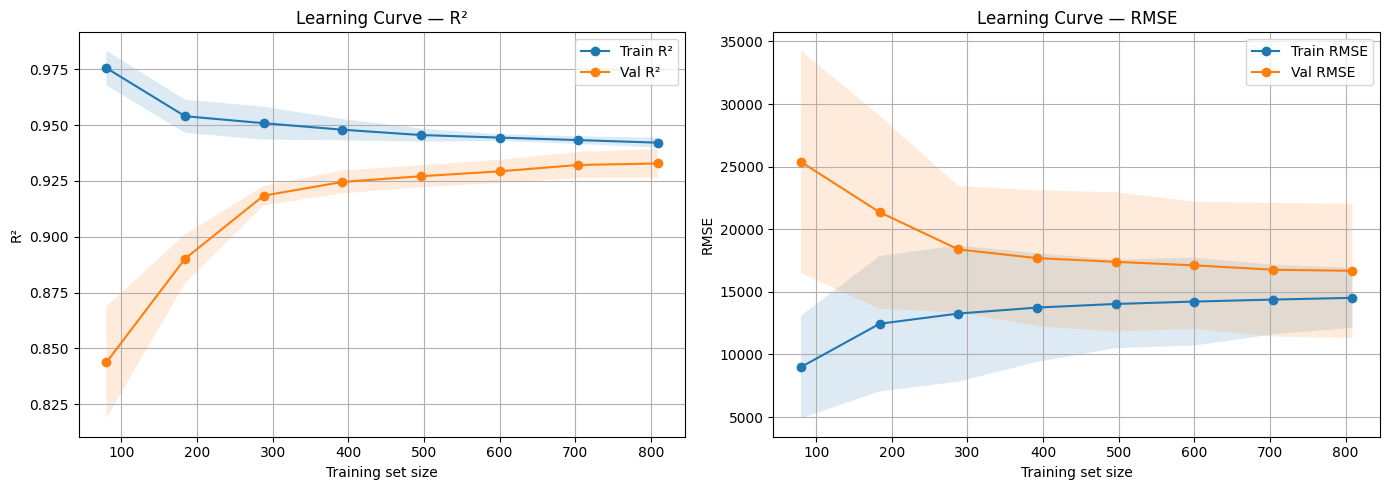

In [49]:
# Learning curve
estimator = Ridge(alpha=10)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

# R²
train_sizes_abs, train_scores_r2, val_scores_r2 = learning_curve(
    estimator,
    X_train, y_train,
    cv=cv,
    train_sizes=train_sizes,
    scoring="r2",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_r2_mean = train_scores_r2.mean(axis=1)
train_r2_std  = train_scores_r2.std(axis=1)
val_r2_mean   = val_scores_r2.mean(axis=1)
val_r2_std    = val_scores_r2.std(axis=1)

# RMSE
train_sizes_abs2, train_scores_nmse, val_scores_nmse = learning_curve(
    estimator,
    X_train, y_train,
    cv=cv,
    train_sizes=train_sizes,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_rmse_mean = np.sqrt(-train_scores_nmse.mean(axis=1))
train_rmse_std  = np.sqrt(train_scores_nmse.std(axis=1))
val_rmse_mean   = np.sqrt(-val_scores_nmse.mean(axis=1))
val_rmse_std    = np.sqrt(val_scores_nmse.std(axis=1))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² plot
axes[0].plot(train_sizes_abs, train_r2_mean, marker='o', label='Train R²')
axes[0].fill_between(train_sizes_abs, train_r2_mean - train_r2_std, train_r2_mean + train_r2_std, alpha=0.15)
axes[0].plot(train_sizes_abs, val_r2_mean, marker='o', label='Val R²')
axes[0].fill_between(train_sizes_abs, val_r2_mean - val_r2_std, val_r2_mean + val_r2_std, alpha=0.15)
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("R²")
axes[0].set_title("Learning Curve — R²")
axes[0].legend()
axes[0].grid(True)

# RMSE plot
axes[1].plot(train_sizes_abs, train_rmse_mean, marker='o', label='Train RMSE')
axes[1].fill_between(train_sizes_abs, np.maximum(0, train_rmse_mean - train_rmse_std), train_rmse_mean + train_rmse_std, alpha=0.15)
axes[1].plot(train_sizes_abs, val_rmse_mean, marker='o', label='Val RMSE')
axes[1].fill_between(train_sizes_abs, np.maximum(0, val_rmse_mean - val_rmse_std), val_rmse_mean + val_rmse_std, alpha=0.15)
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Learning Curve — RMSE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The validation curves confirm that Ridge Regression behaves as expected for increasing regularization. As alpha increases from 1 to 6, both the training and validation R² scores decrease slightly, while the MSE increases. This indicates that stronger regularization makes the model simpler and slightly underfits. The curves show that smaller alpha values (around 1–2) give the best trade-off between bias and variance, which aligns with the earlier GridSearch result where α ≈ 2.07 produced the lowest RMSE. Overall, the validation curves validate the stability of the chosen Ridge model and illustrate how regularization affects model performance.

## Error analysis

In [55]:
# predictions & residuals
y_pred = model.predict(X_val)
residuals = y_val.values.flatten() - y_pred.flatten()
abs_err = np.abs(residuals)

df_err = pd.DataFrame({
    "Actual": y_val.values.flatten(),
    "Predicted": y_pred.flatten(),
    "Residual": residuals,
    "AbsError": abs_err
}, index=y_val.index)

# key metrics
mae = mean_absolute_error(df_err["Actual"], df_err["Predicted"])
rmse = np.sqrt(mean_squared_error(df_err["Actual"], df_err["Predicted"]))
r2  = r2_score(df_err["Actual"], df_err["Predicted"])
mape = np.mean(np.abs((df_err["Actual"] - df_err["Predicted"]) / df_err["Actual"])) * 100.0

print(f"MAE   = {mae:,.2f}")
print(f"RMSE  = {rmse:,.2f}")
print(f"R²    = {r2:0.4f}")
print(f"MAPE% = {mape:0.2f}%")
print(f"Residual mean = {df_err['Residual'].mean():.2f}, std = {df_err['Residual'].std():.2f}")

MAE   = 15,627.57
RMSE  = 21,347.87
R²    = 0.8798
MAPE% = 9.83%
Residual mean = 1804.67, std = 21324.30


In [52]:
# top absolute errors
top_n = 10
print(f"\nTop {top_n} absolute errors:")
display(df_err.sort_values("AbsError", ascending=False).head(top_n))


Top 10 absolute errors:


,Actual,Predicted,Residual,AbsError,Pred_bin
1029,392500.0,276800.826688,115699.173312,115699.173312,"(220915.958, 343350.003]"
753,250580.0,196728.178071,53851.821929,53851.821929,"(192352.715, 220915.958]"
845,135000.0,81629.354776,53370.645224,53370.645224,"(31180.082, 115836.766]"
861,395192.0,343350.003273,51841.996727,51841.996727,"(220915.958, 343350.003]"
574,97500.0,149065.535888,-51565.535888,51565.535888,"(137122.899, 163067.919]"
927,151400.0,202532.600342,-51132.600342,51132.600342,"(192352.715, 220915.958]"
285,214500.0,165231.504976,49268.495024,49268.495024,"(163067.919, 192352.715]"
283,324000.0,274866.466469,49133.533531,49133.533531,"(220915.958, 343350.003]"
582,137500.0,89373.942018,48126.057982,48126.057982,"(31180.082, 115836.766]"
939,145000.0,189814.433997,-44814.433997,44814.433997,"(163067.919, 192352.715]"


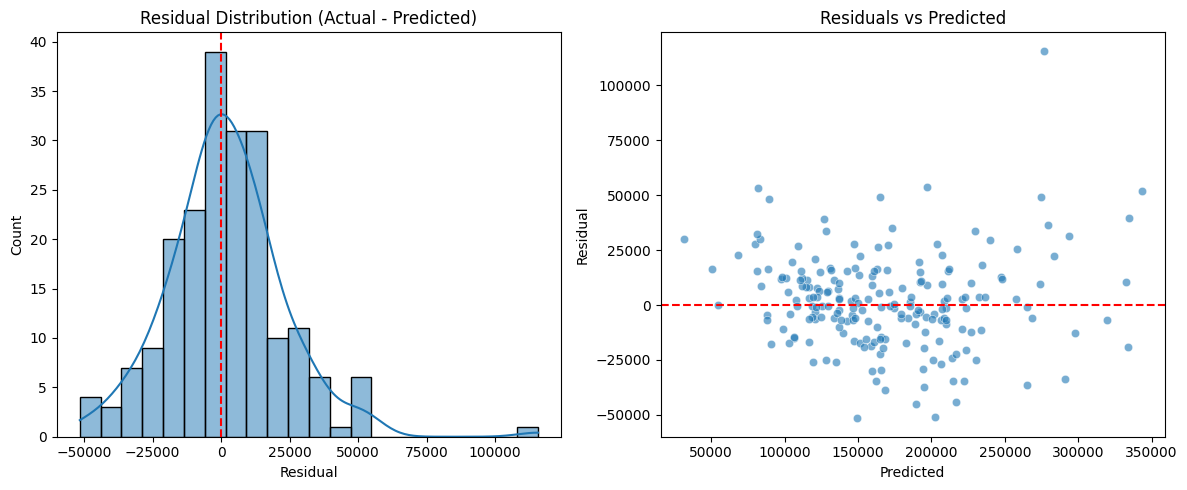

In [ ]:
# Residual distribution and Residuals vs Predicted
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_err["Residual"], kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")

plt.subplot(1,2,2)
sns.scatterplot(x=df_err["Predicted"], y=df_err["Residual"], alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


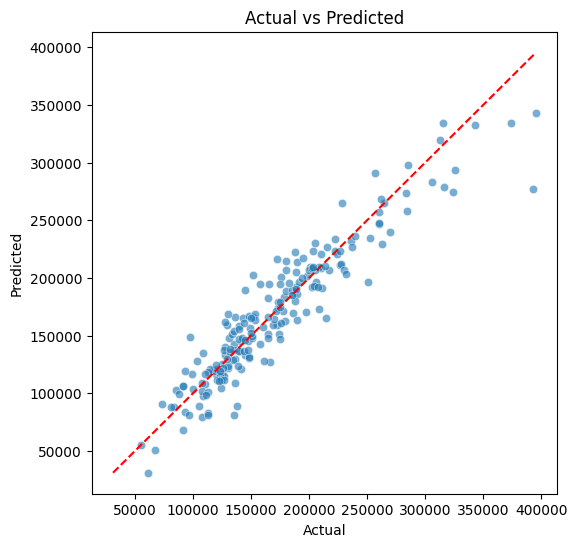

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=df_err["Actual"], y=df_err["Predicted"], alpha=0.6)
mn, mx = min(df_err["Actual"].min(), df_err["Predicted"].min()), max(df_err["Actual"].max(), df_err["Predicted"].max())
plt.plot([mn,mx],[mn,mx], color="red", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


## SHAP and feature explainability

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


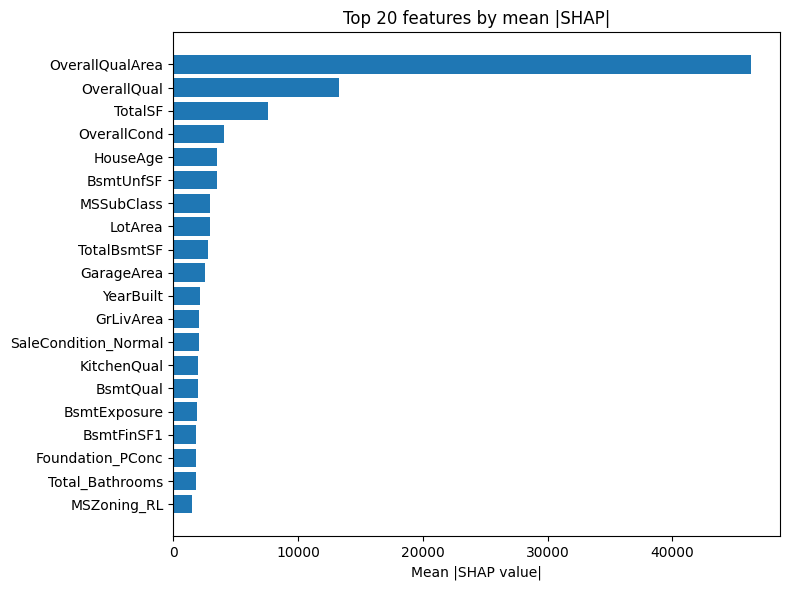

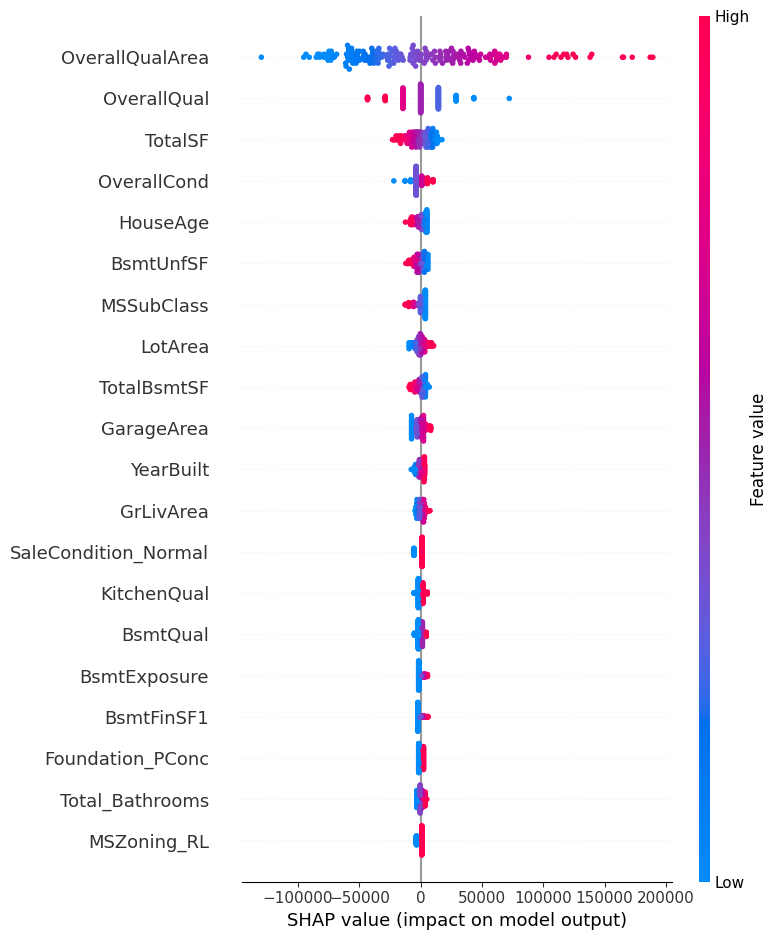

In [64]:
# pick final model
model = None
if 'best_ridge' in globals():
    model = best_ridge
elif 'grid' in globals() and hasattr(grid, "best_estimator_"):
    model = grid.best_estimator_
else:
    raise RuntimeError("Define 'best_ridge' or run GridSearchCV into 'grid' first.")

X_train_arr = X_train.values if hasattr(X_train, "values") else np.asarray(X_train)
X_val_arr   = X_val.values   if hasattr(X_val, "values")   else np.asarray(X_val)

X_train_arr = X_train_arr.astype(np.float64)
X_val_arr   = X_val_arr.astype(np.float64)

bg_n = min(100, X_train_arr.shape[0])
rng = np.random.RandomState(42)
bg_idx = rng.choice(np.arange(X_train_arr.shape[0]), size=bg_n, replace=False)
background = X_train_arr[bg_idx]

# explainer and SHAP values
explainer = shap.LinearExplainer(model, background, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_val_arr) 
shap_values = np.asarray(shap_values, dtype=np.float64)

# Top-20 mean absolute SHAP bar plot
feature_names = X_val.columns.tolist() if hasattr(X_val, "columns") else [f"f{i}" for i in range(X_val_arr.shape[1])]
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(-mean_abs)[:20]
top_feats = [feature_names[i] for i in top_idx]

plt.figure(figsize=(8,6))
plt.barh(top_feats[::-1], mean_abs[top_idx][::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 features by mean |SHAP|")
plt.tight_layout()
plt.show()

# SHAP summary plot
try:
    shap.summary_plot(shap_values, X_val, plot_type="dot", max_display=20)
except Exception:
    shap.summary_plot(shap_values, X_val_arr, feature_names=feature_names, plot_type="dot", max_display=20)

The SHAP beeswarm plot provides instance-level insight into how feature values affect individual predictions. High values (in red) for key features push predictions upward, while low values (in blue) push them downward. This indicates stable, monotonic relationships that align with the linear structure of the model. The spread of SHAP values also shows which features create the most variability across homes, with quality and area features dominating.

## Final Prediction & Submission

In [65]:
best_alpha = grid.best_params_["alpha"]
print("Best Ridge alpha:", best_alpha)

final_model = Ridge(alpha=best_alpha, random_state=42)
final_model.fit(X, y)

test_ids = test["Id"]
X_test = test.drop(columns=["Id"], errors="ignore")

X_test = X_test.reindex(columns=X.columns, fill_value=0.0)

# Predict
y_test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred
})

submission.to_csv("submission.csv", index=False)

Best Ridge alpha: 10


In [67]:
# Save the final trained Ridge model
joblib.dump(final_model, "ridge_model.pkl")

# Save feature list
feature_list = X.columns.tolist()
joblib.dump(feature_list, "feature_list.pkl")

['feature_list.pkl']